# Análisis de Datos Intact

In: dataset `database_intact.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import os
import gc

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
%matplotlib inline

## Cargar dataset Sujetos NO amputados

In [17]:
# Dolor de cabeza... cómo se unen según sujeto, estimulo, base de datos y canal
meta_cols = ['subject', 'stimulus', 'origin_db','repetition']
# Features
features = ['VAR_STD', 'Range', 'Energy', 'Peak_to_Peak', 'VAR', 'Max', 'MNF', 'SSC']
# Channel 1..8 × features
signal_cols = [f'Channel {ch}_{feat}' for ch in range(1, 9) for feat in features]
# Estímulos de interés (nos falta el reposo)
selected_stimuli = [0, 22, 25, 27, 30, 31, 37, 40]

print(f'Features       : {len(features)}')
print(f'Canales        : 8  →  columnas de señal: {len(signal_cols)}')
print(f'Estímulos selec: {selected_stimuli}')

# dataset 
path_dataset = '../data/master/database_intact.csv'
df_intact = pd.read_csv(path_dataset)
print(f'Shape dataset: {df_intact.shape}')
df_intact.head(30)

Features       : 8
Canales        : 8  →  columnas de señal: 64
Estímulos selec: [0, 22, 25, 27, 30, 31, 37, 40]
Shape dataset: (407086, 68)


,subject,stimulus,origin_db,repetition,Channel 1_VAR_STD,Channel 1_Range,Channel 1_Energy,Channel 1_Peak_to_Peak,Channel 1_VAR,Channel 1_Max,...,Channel 7_MNF,Channel 7_SSC,Channel 8_VAR_STD,Channel 8_Range,Channel 8_Energy,Channel 8_Peak_to_Peak,Channel 8_VAR,Channel 8_Max,Channel 8_MNF,Channel 8_SSC
0,1,22,NinaProDB1,1,0.001033,0.040034,9.149888,0.0611,1.477702e-04,0.695626,...,5.961012,2,0.000932,0.071187,7.951489,0.0317,0.000467,0.665271,3.388667,4
1,1,22,NinaProDB1,1,0.000046,0.048506,7.932059,0.0122,2.169982e-04,0.653253,...,5.172572,4,0.000950,0.076264,6.109683,0.0342,0.000537,0.590169,4.875131,3
2,1,22,NinaProDB1,1,0.000000,0.055218,6.613127,0.0000,2.813390e-04,0.601996,...,8.095824,3,0.000486,0.072910,4.477883,0.0244,0.000493,0.509871,3.115516,3
3,1,22,NinaProDB1,1,0.000048,0.058243,5.303784,0.0098,3.132917e-04,0.543751,...,11.251693,4,0.005782,0.054283,3.274406,0.1123,0.000275,0.433467,7.660429,0
4,1,22,NinaProDB1,1,0.000004,0.055119,4.134773,0.0025,2.810018e-04,0.482461,...,3.711943,4,0.002377,0.019837,2.653012,0.0537,0.000039,0.377117,2.589679,4
5,1,22,NinaProDB1,1,0.000046,0.043684,3.229690,0.0098,1.770469e-04,0.424665,...,3.950488,2,0.002755,0.022272,2.670651,0.0512,0.000049,0.379607,3.427735,4
6,1,22,NinaProDB1,1,0.000160,0.023916,2.672116,0.0245,5.377954e-05,0.379140,...,10.654974,4,0.015981,0.057321,3.343680,0.1880,0.000307,0.439152,9.079539,1
7,1,22,NinaProDB1,1,0.008077,0.003245,2.492335,0.1319,9.742220e-07,0.355155,...,5.442071,6,0.120545,0.071460,4.586641,0.4052,0.000475,0.514219,4.342650,1
8,1,22,NinaProDB1,1,0.006998,0.023225,2.679739,0.0684,5.072735e-05,0.379052,...,7.959532,1,0.079875,0.061419,6.059224,0.2857,0.000350,0.579318,3.258679,4
9,1,22,NinaProDB1,1,0.039785,0.037776,3.185912,0.2172,1.326119e-04,0.418522,...,1.830359,3,0.034738,0.036814,7.260615,0.1733,0.000126,0.618780,2.803425,4


### Número de sujetos por estímulo y por database

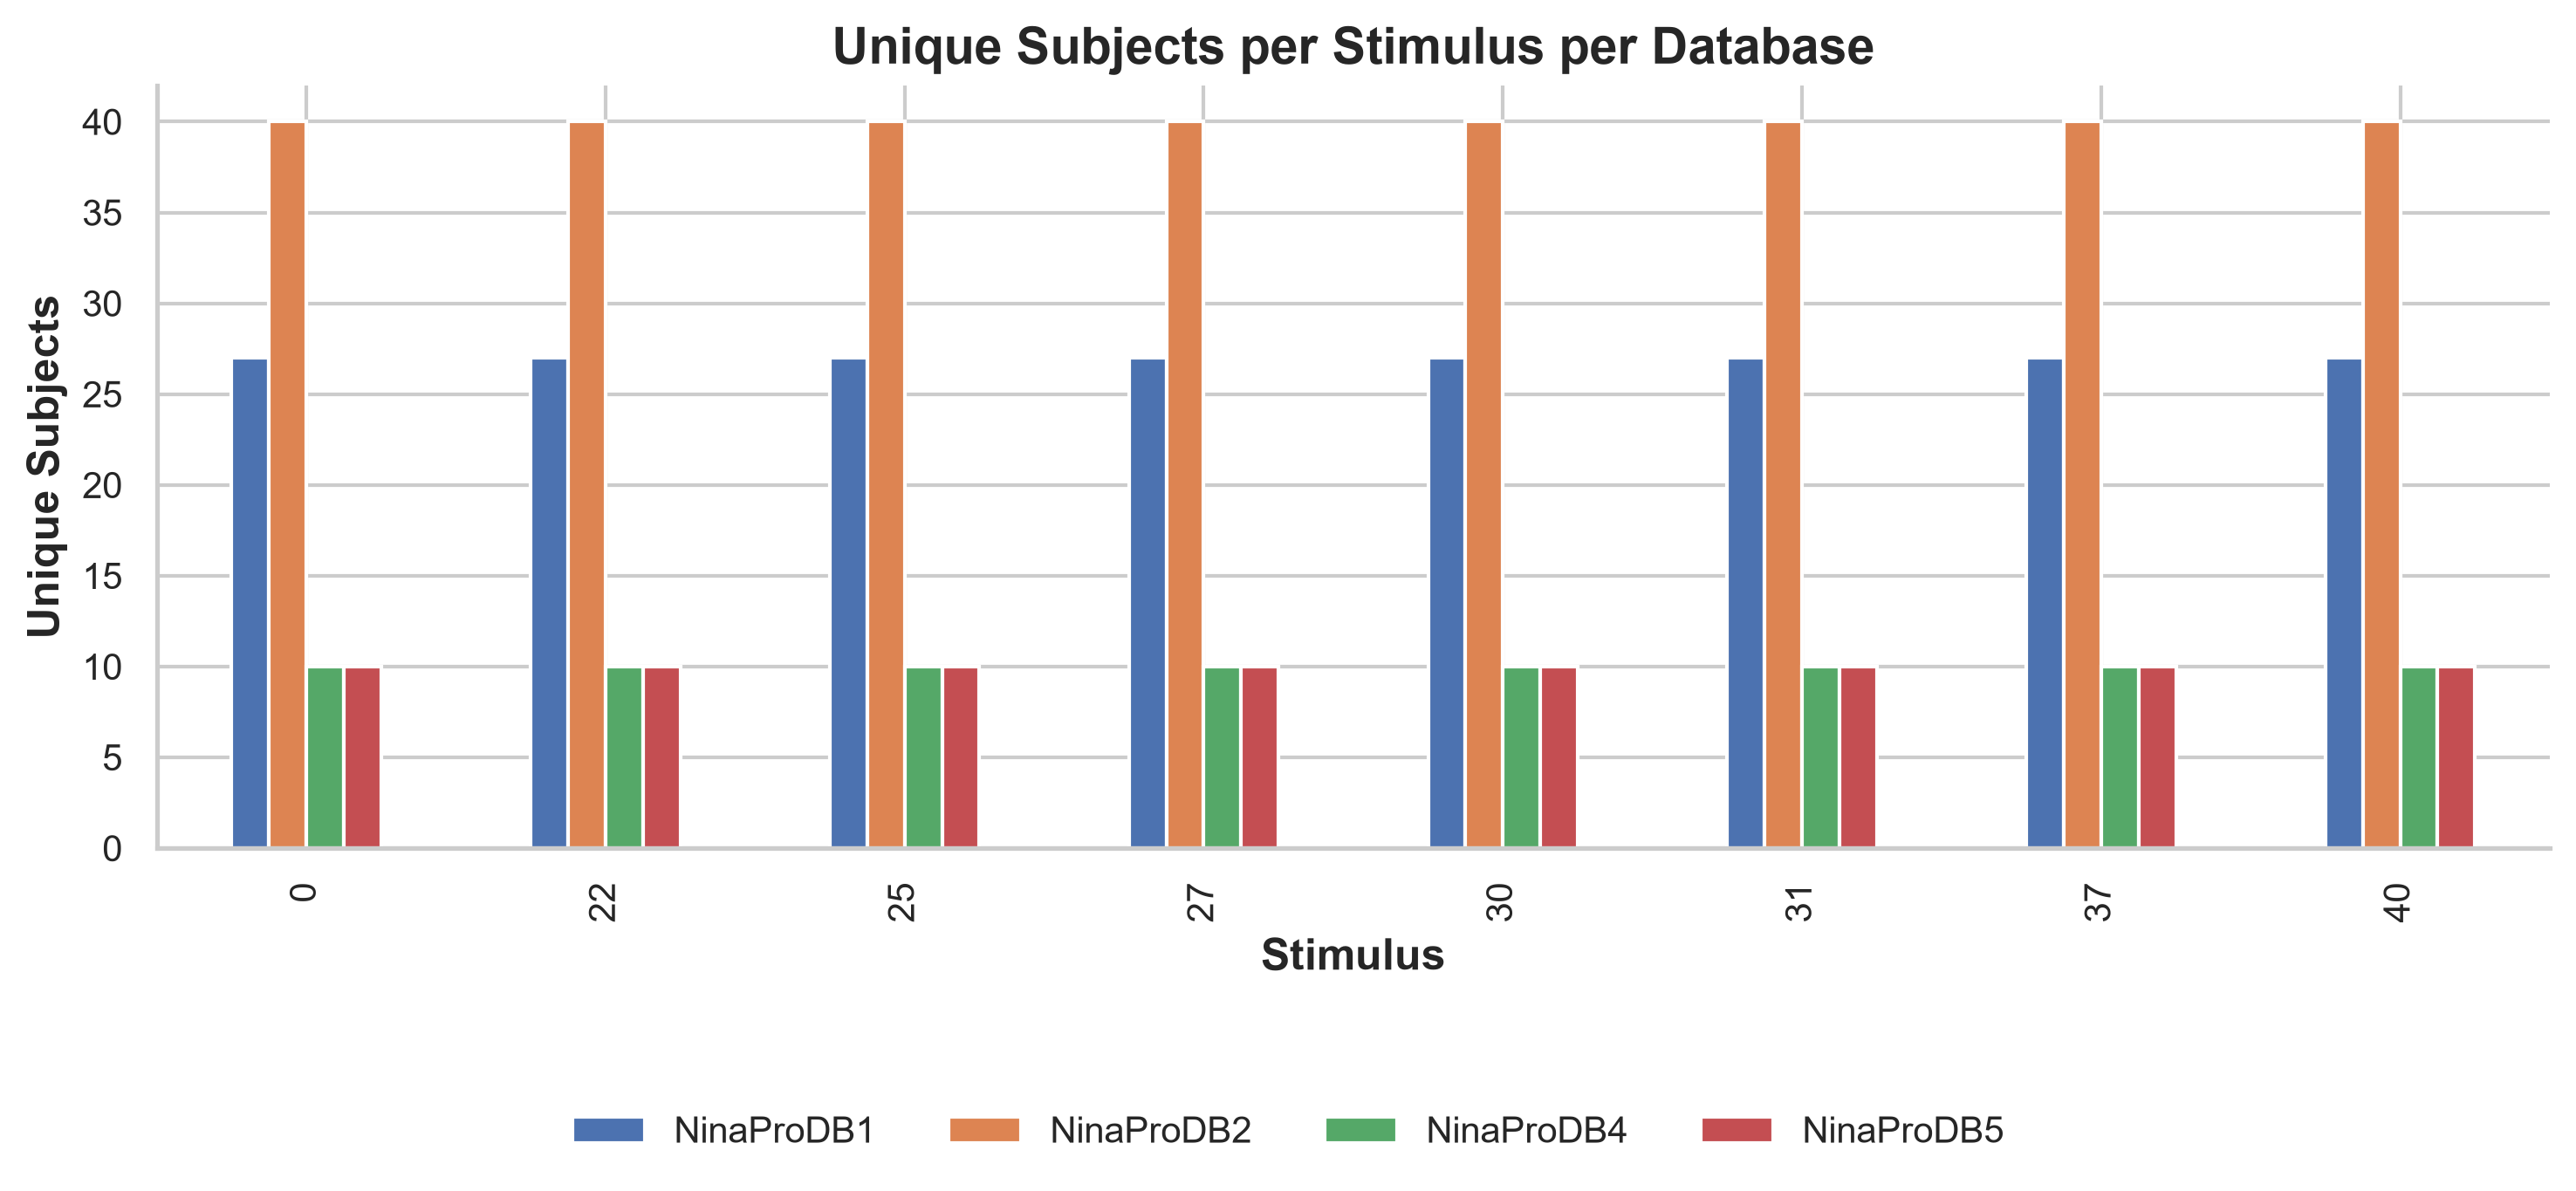

In [3]:
# Sujeto x stimuls x base de datos
summary = df_intact.groupby(['origin_db', 'stimulus'])['subject'].nunique().reset_index().rename(columns={'subject': 'unique_subjects'}).sort_values(['origin_db', 'stimulus'])
pivot = summary.pivot(index='origin_db', columns='stimulus', values='unique_subjects')
# Imagen
fig, ax = plt.subplots(figsize=(10, 4), dpi=300)
pivot.T.plot(kind='bar', ax=ax, edgecolor='white', legend=False)
ax.set_xlabel('Stimulus', fontsize=12, fontweight='bold'); ax.set_ylabel('Unique Subjects', fontsize=12, fontweight='bold'); ax.set_title('Unique Subjects per Stimulus per Database', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', labelsize=10); ax.spines[['top', 'right']].set_visible(False)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=len(pivot.index), fontsize=10, frameon=False)
plt.tight_layout();
plt.savefig('../figures/unique_subjects_per_stimulus.pdf', dpi=300, bbox_inches='tight'); 
plt.show()

In [4]:
# Número de registros por estimulos
display(df_intact['stimulus'].value_counts().sort_index())

stimulus
0     288468
22     16832
25     17034
27     17030
30     17039
31     16997
37     16840
40     16846
Name: count, dtype: int64

### Número de ventanas por sujeto en cada base de datos

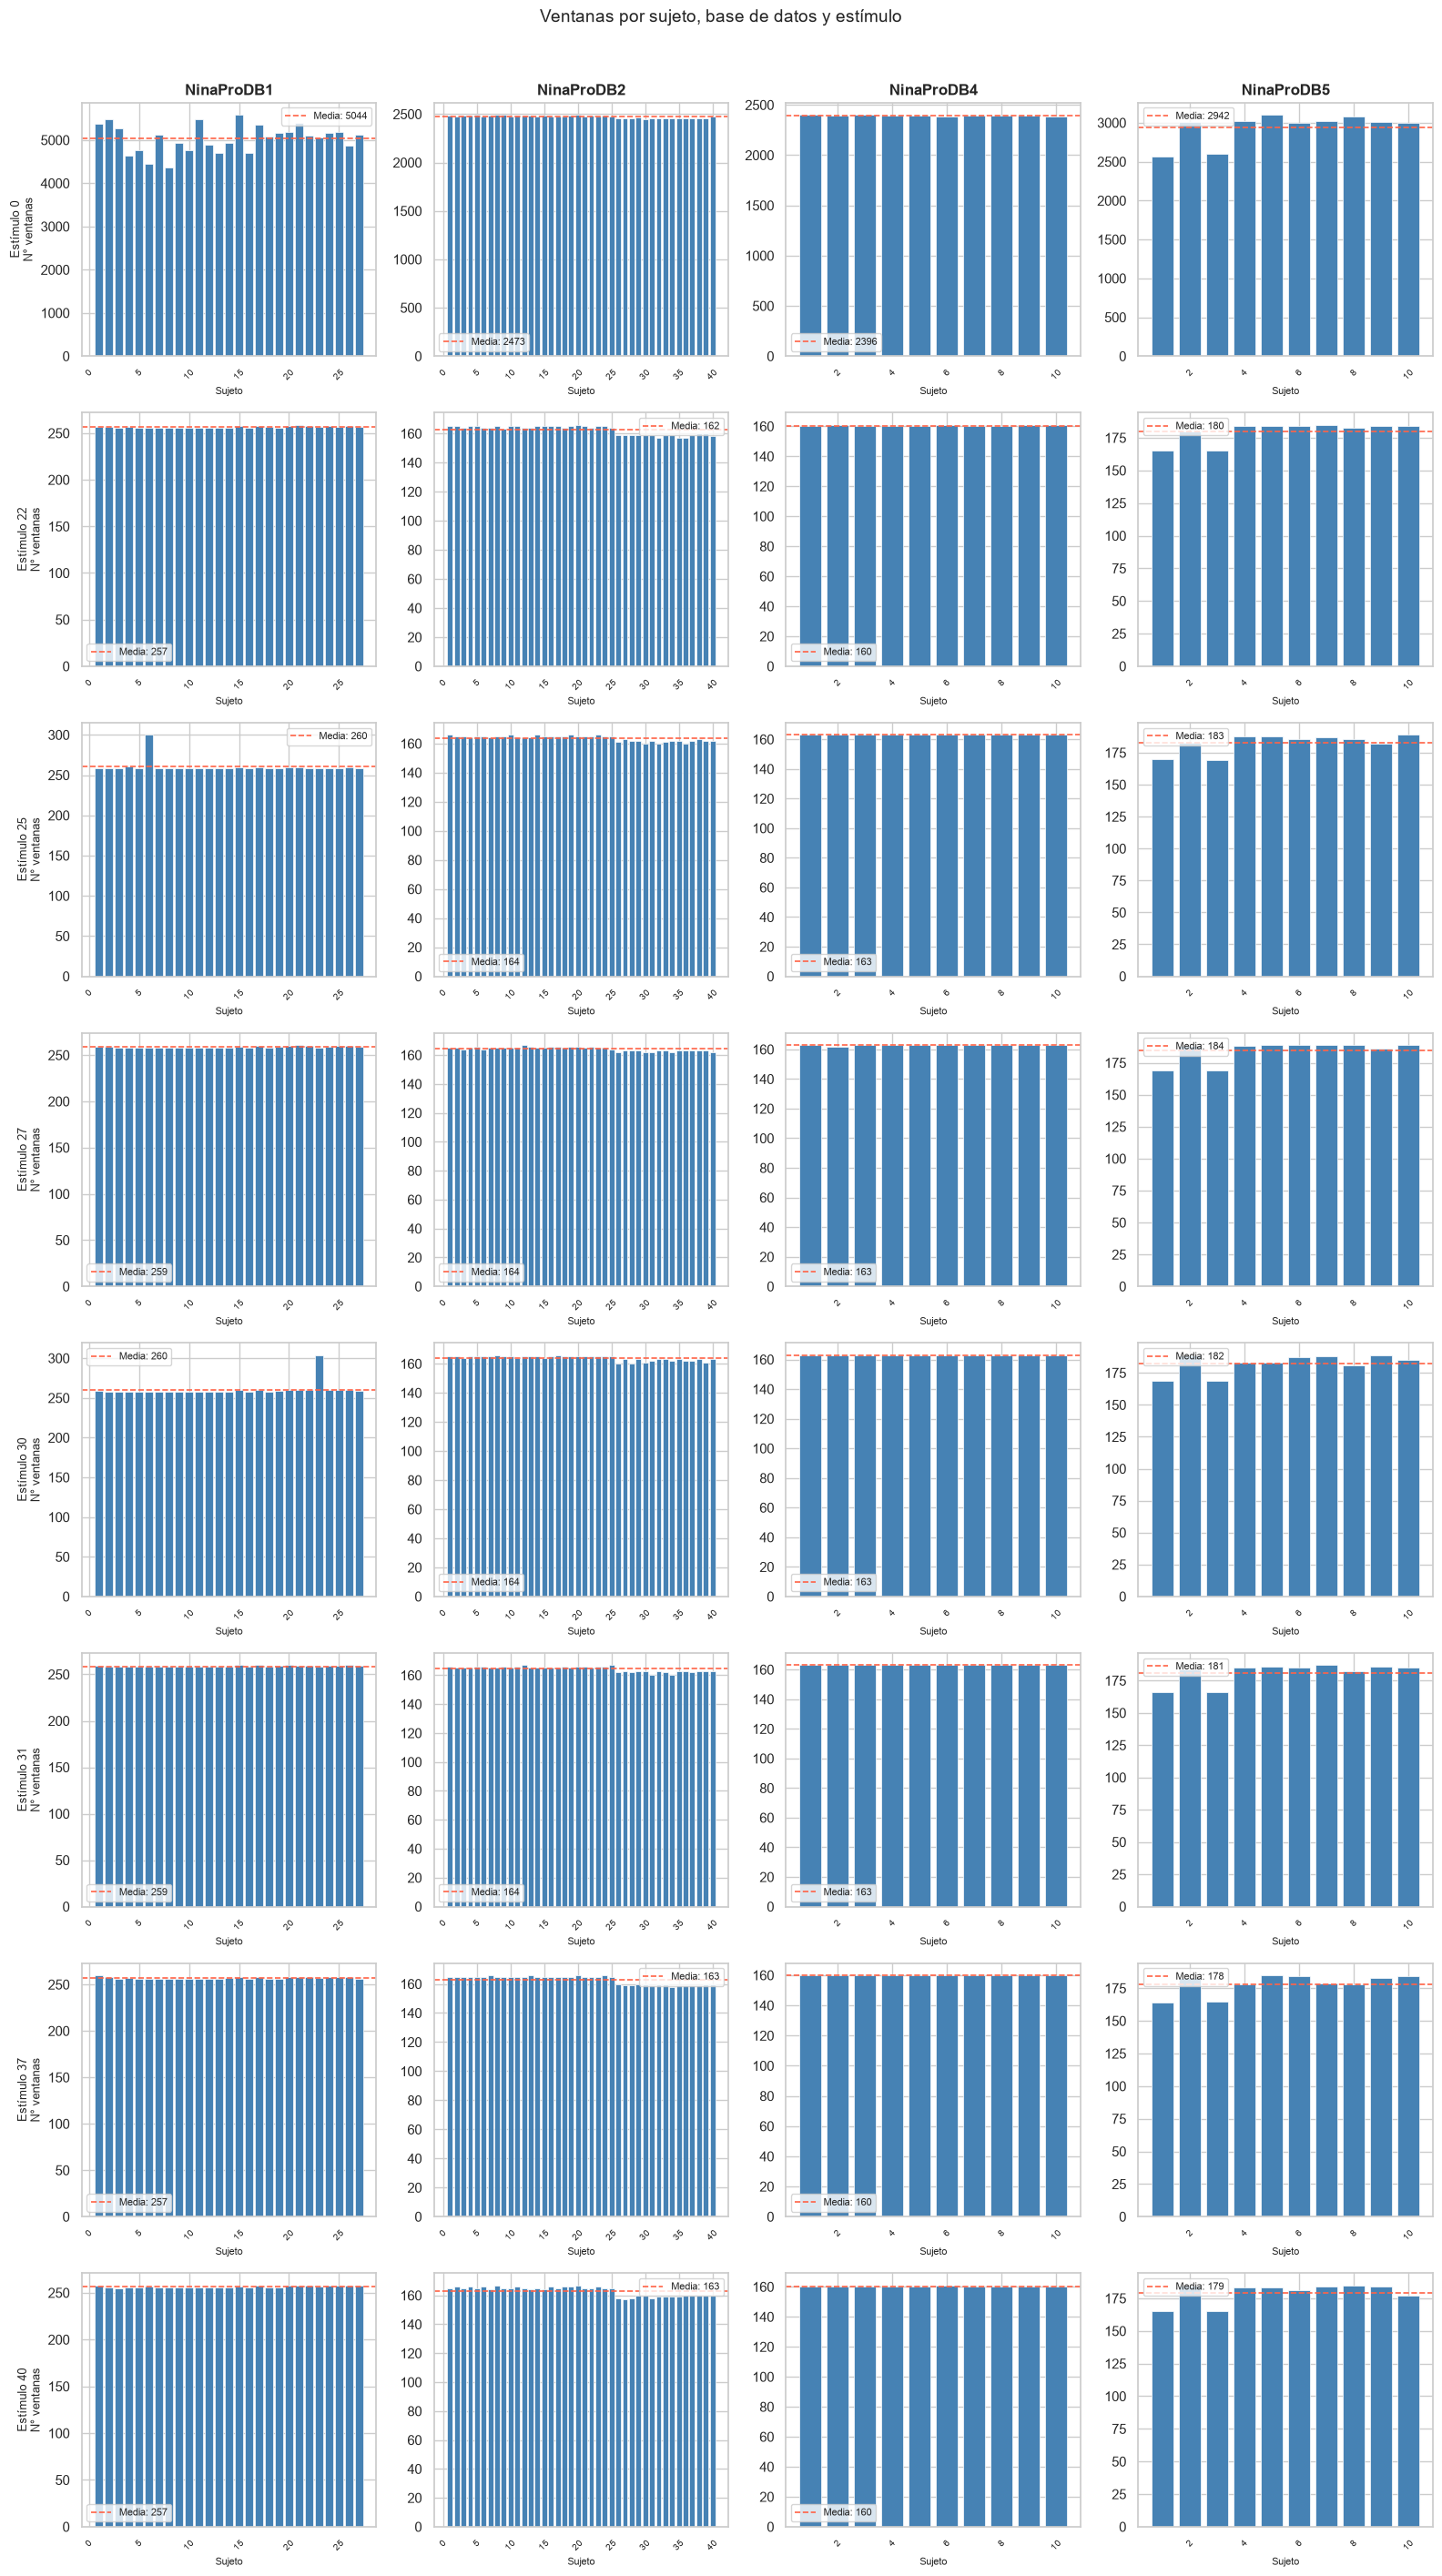

In [5]:
# Cada fila corresponde a un estímulo 
window_count = df_intact.groupby(['origin_db', 'stimulus', 'subject']).size().reset_index(name='n_windows')

databases = sorted(window_count['origin_db'].unique())
stimuli   = sorted(window_count['stimulus'].unique())

n_rows = len(stimuli)
n_cols = len(databases)

fig, axes = plt.subplots(n_rows, n_cols, 
                          figsize=(4 * n_cols, 3.5 * n_rows), 
                          sharey=False)

# Asegurar siempre matriz 2D
if n_rows == 1: axes = [axes]
if n_cols == 1: axes = [[ax] for ax in axes]

for row, stim in enumerate(stimuli):
    for col, db in enumerate(databases):
        ax = axes[row][col]

        data = window_count[
            (window_count['origin_db'] == db) & 
            (window_count['stimulus'] == stim)
        ]

        if data.empty:
            ax.set_visible(False)
            continue

        ax.bar(data['subject'], data['n_windows'], 
               color='steelblue', edgecolor='white', linewidth=0.5)

        mean_val = data['n_windows'].mean()
        ax.axhline(mean_val, color='tomato', linestyle='--', 
                   linewidth=1.2, label=f'Media: {mean_val:.0f}')

        # Títulos solo en primera fila y primera columna
        if row == 0:
            ax.set_title(db, fontsize=12, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'Estímulo {stim}\nN° ventanas', fontsize=9)

        ax.set_xlabel('Sujeto', fontsize=8)
        ax.legend(fontsize=8)
        ax.tick_params(axis='x', rotation=45, labelsize=7)

plt.suptitle('Ventanas por sujeto, base de datos y estímulo', fontsize=14, y=1.01)
plt.tight_layout()
#plt.savefig('../figures/ventanas_por_sujeto_stimulus.png', dpi=150, bbox_inches='tight')
plt.show()

### Repeticiones por sujeto por agarre

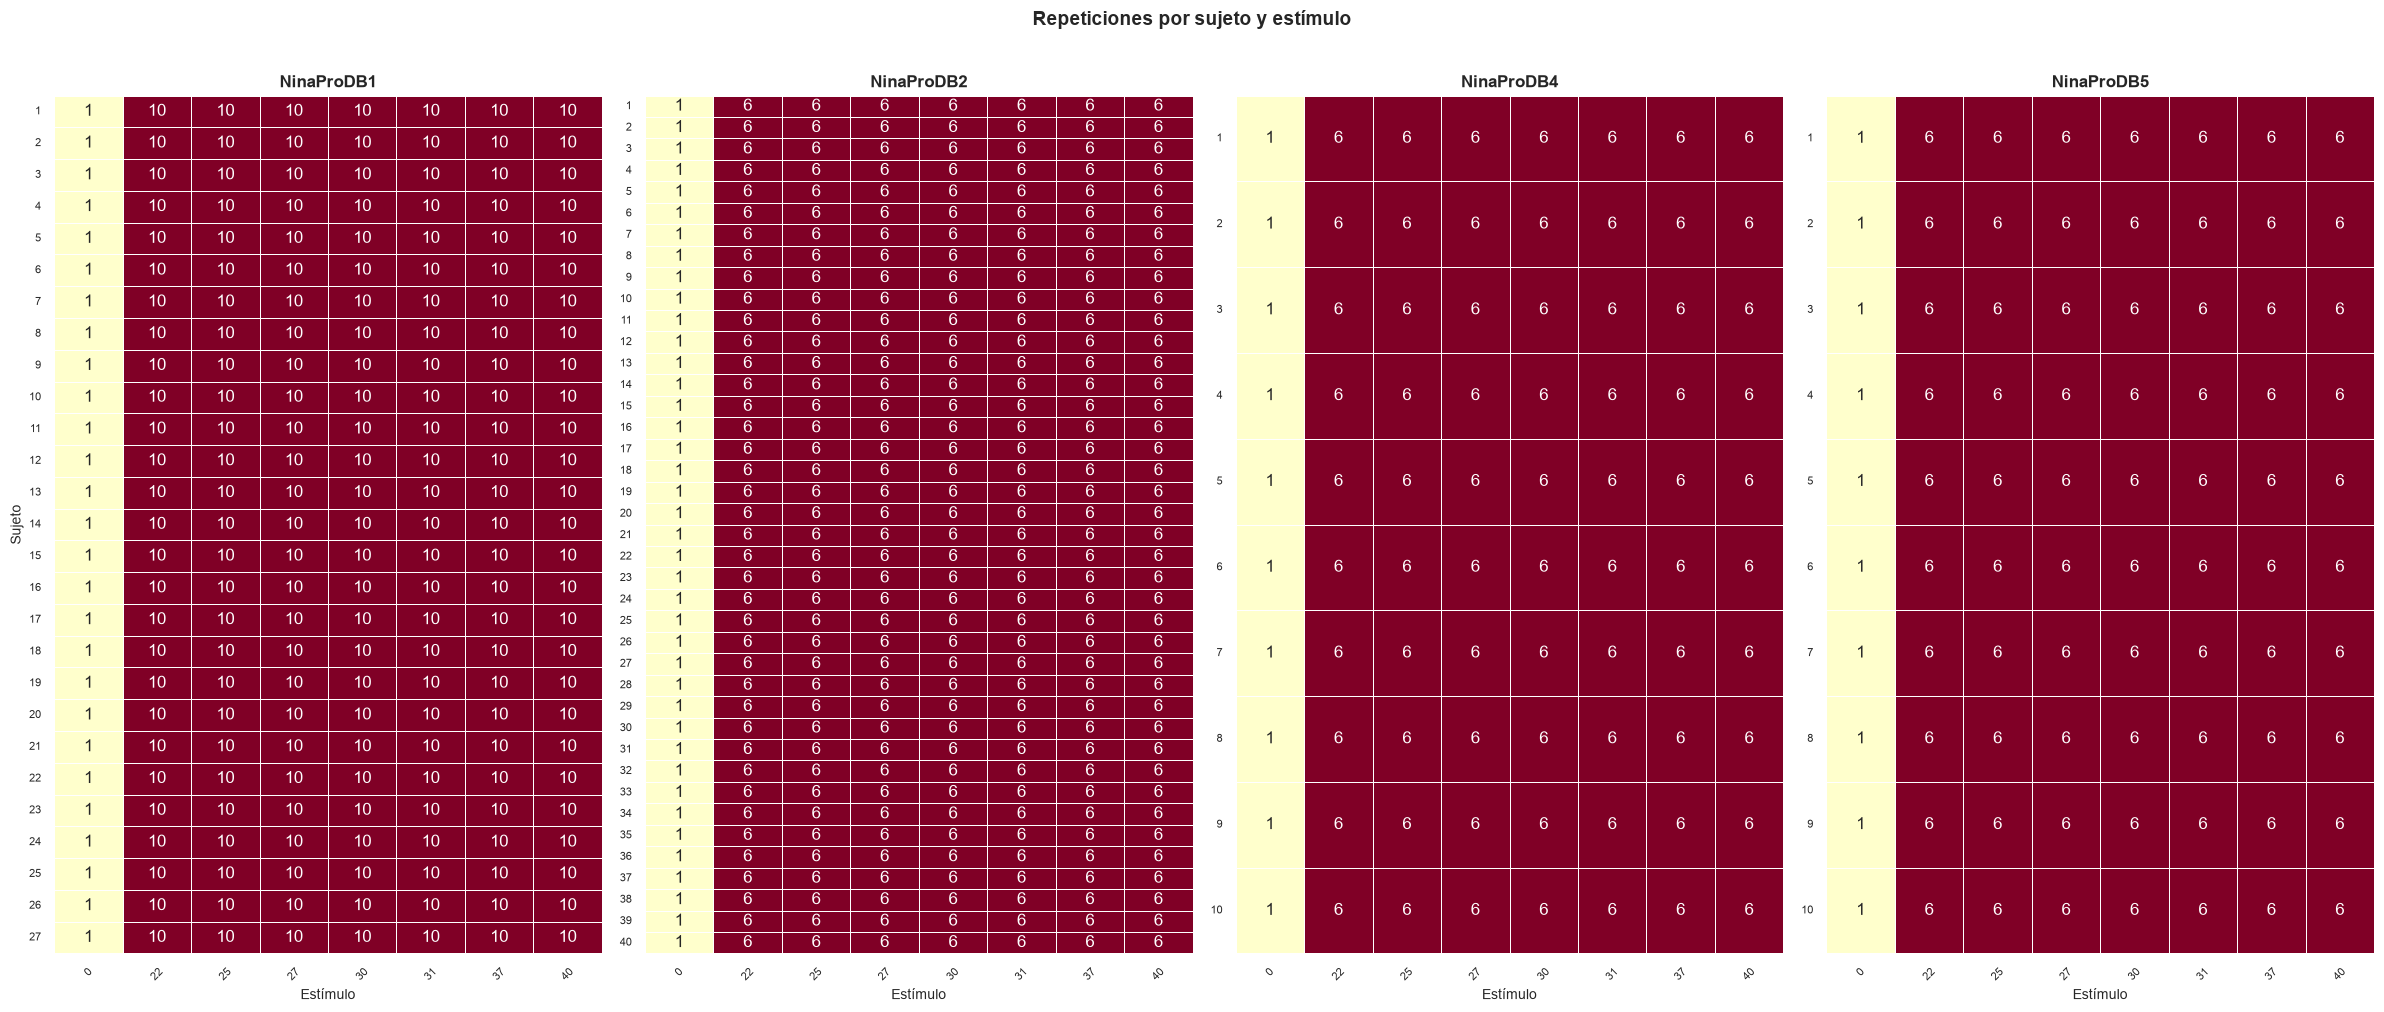

In [6]:
# Número de repeticiones por sujeto x stimulus según cada database
databases = sorted(df_intact['origin_db'].unique())
n_dbs = len(databases)

fig, axes = plt.subplots(1, n_dbs, figsize=(6 * n_dbs, 10))

if n_dbs == 1:
    axes = [axes]

for ax, db in zip(axes, databases):
    df_db = df_intact[df_intact['origin_db'] == db]
    
    rep_map = df_db.groupby(['subject', 'stimulus'])['repetition'].nunique().reset_index()
    rep_pivot = rep_map.pivot(index='subject', columns='stimulus', values='repetition')
    
    sns.heatmap(rep_pivot,
                annot=True, fmt='.0f',
                cmap='YlOrRd',
                linewidths=0.5,
                linecolor='white',
                ax=ax,
                cbar=False)
    
    ax.set_title(db, fontsize=12, fontweight='bold')
    ax.set_xlabel('Estímulo', fontsize=10)
    ax.set_ylabel('Sujeto' if ax == axes[0] else '', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.suptitle('Repeticiones por sujeto y estímulo', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
#plt.savefig('../figures/repeticiones_all_dbs.png', dpi=150, bbox_inches='tight')
plt.show()

## Análisis de Ventanas

In [7]:
# Número de ventanas por repetición por sujeto
summary = (df_intact.groupby(['origin_db', 'subject', 'stimulus', 'repetition']).size().reset_index(name='n_windows'))

print(summary.to_string(index=False))

 origin_db  subject  stimulus  repetition  n_windows
NinaProDB1        1         0           0       5382
NinaProDB1        1        22           1         26
NinaProDB1        1        22           2         26
NinaProDB1        1        22           3         25
NinaProDB1        1        22           4         26
NinaProDB1        1        22           5         26
NinaProDB1        1        22           6         26
NinaProDB1        1        22           7         25
NinaProDB1        1        22           8         26
NinaProDB1        1        22           9         26
NinaProDB1        1        22          10         25
NinaProDB1        1        25           1         26
NinaProDB1        1        25           2         26
NinaProDB1        1        25           3         26
NinaProDB1        1        25           4         26
NinaProDB1        1        25           5         26
NinaProDB1        1        25           6         26
NinaProDB1        1        25           7     

### Coeficiente de variación (CV)

- CV < 0.10 → ventanas muy similares → cualquier estrategia nos puede servir para unir las ventanas
- CV 0.10–0.30 → variabilidad moderada 
- CV > 0.30 

In [8]:
# ¿Cuánta variabilidad hay dentro de cada repetición?
# Output: archivo CV_analysis.xlsx en la carpeta resultados 

from openpyxl.styles import PatternFill, Font
from openpyxl.utils import get_column_letter

writer = pd.ExcelWriter('../resultados/CV_analysis.xlsx', engine='openpyxl')

# ── Acumulador global de df_cv ────────────────────────────────────────────────
all_cv = []  

for feature in features:
    feat_cols = [f'Channel {ch}_{feature}' for ch in range(1, 9)
                 if f'Channel {ch}_{feature}' in df_intact.columns]

    dfs_db = []

    for db in sorted(df_intact['origin_db'].unique()):
        df_db = df_intact[df_intact['origin_db'] == db]

        rows = []
        for col in feat_cols:
            cv_data = (df_db
                .groupby(['subject', 'stimulus', 'repetition'])[col]
                .agg(['mean', 'std'])
                .eval('cv = std / mean')
                ['cv']
                .reset_index())
            cv_data['channel']   = col
            cv_data['feature']   = feature   # ← agregar feature
            cv_data['origin_db'] = db
            rows.append(cv_data)

        df_cv_db = pd.concat(rows, ignore_index=True)
        all_cv.append(df_cv_db)              # ← acumular

        summary = (df_cv_db
            .groupby(['subject', 'stimulus'])['cv']
            .agg(['mean', 'std', 'min', 'max'])
            .round(3)
            .reset_index())
        summary.columns = ['subject', 'stimulus', 'cv_mean', 'cv_std', 'cv_min', 'cv_max']
        summary.insert(0, 'origin_db', db)
        dfs_db.append(summary)

    df_sheet = pd.concat(dfs_db, ignore_index=True)
    df_sheet.to_excel(writer, sheet_name=feature, index=False)

    ws = writer.sheets[feature]
    for cell in ws[1]:
        cell.font = Font(bold=True)

    red    = PatternFill('solid', fgColor='FF9999')
    yellow = PatternFill('solid', fgColor='FFFF99')
    green  = PatternFill('solid', fgColor='CCFFCC')

    cv_col = 4
    for row in ws.iter_rows(min_row=2, min_col=cv_col, max_col=cv_col):
        for cell in row:
            if cell.value is None:
                continue
            if cell.value > 0.30:
                cell.fill = red
            elif cell.value > 0.10:
                cell.fill = yellow
            else:
                cell.fill = green

    for col in ws.columns:
        max_len = max(len(str(c.value)) if c.value else 0 for c in col) + 2
        ws.column_dimensions[get_column_letter(col[0].column)].width = max_len

writer.close()

# Resultados de comparación
df_cv = pd.concat(all_cv, ignore_index=True)
print(f"df_cv shape: {df_cv.shape}")
print(f"Columnas: {df_cv.columns.tolist()}")

df_cv shape: (287808, 7)
Columnas: ['subject', 'stimulus', 'repetition', 'cv', 'channel', 'feature', 'origin_db']


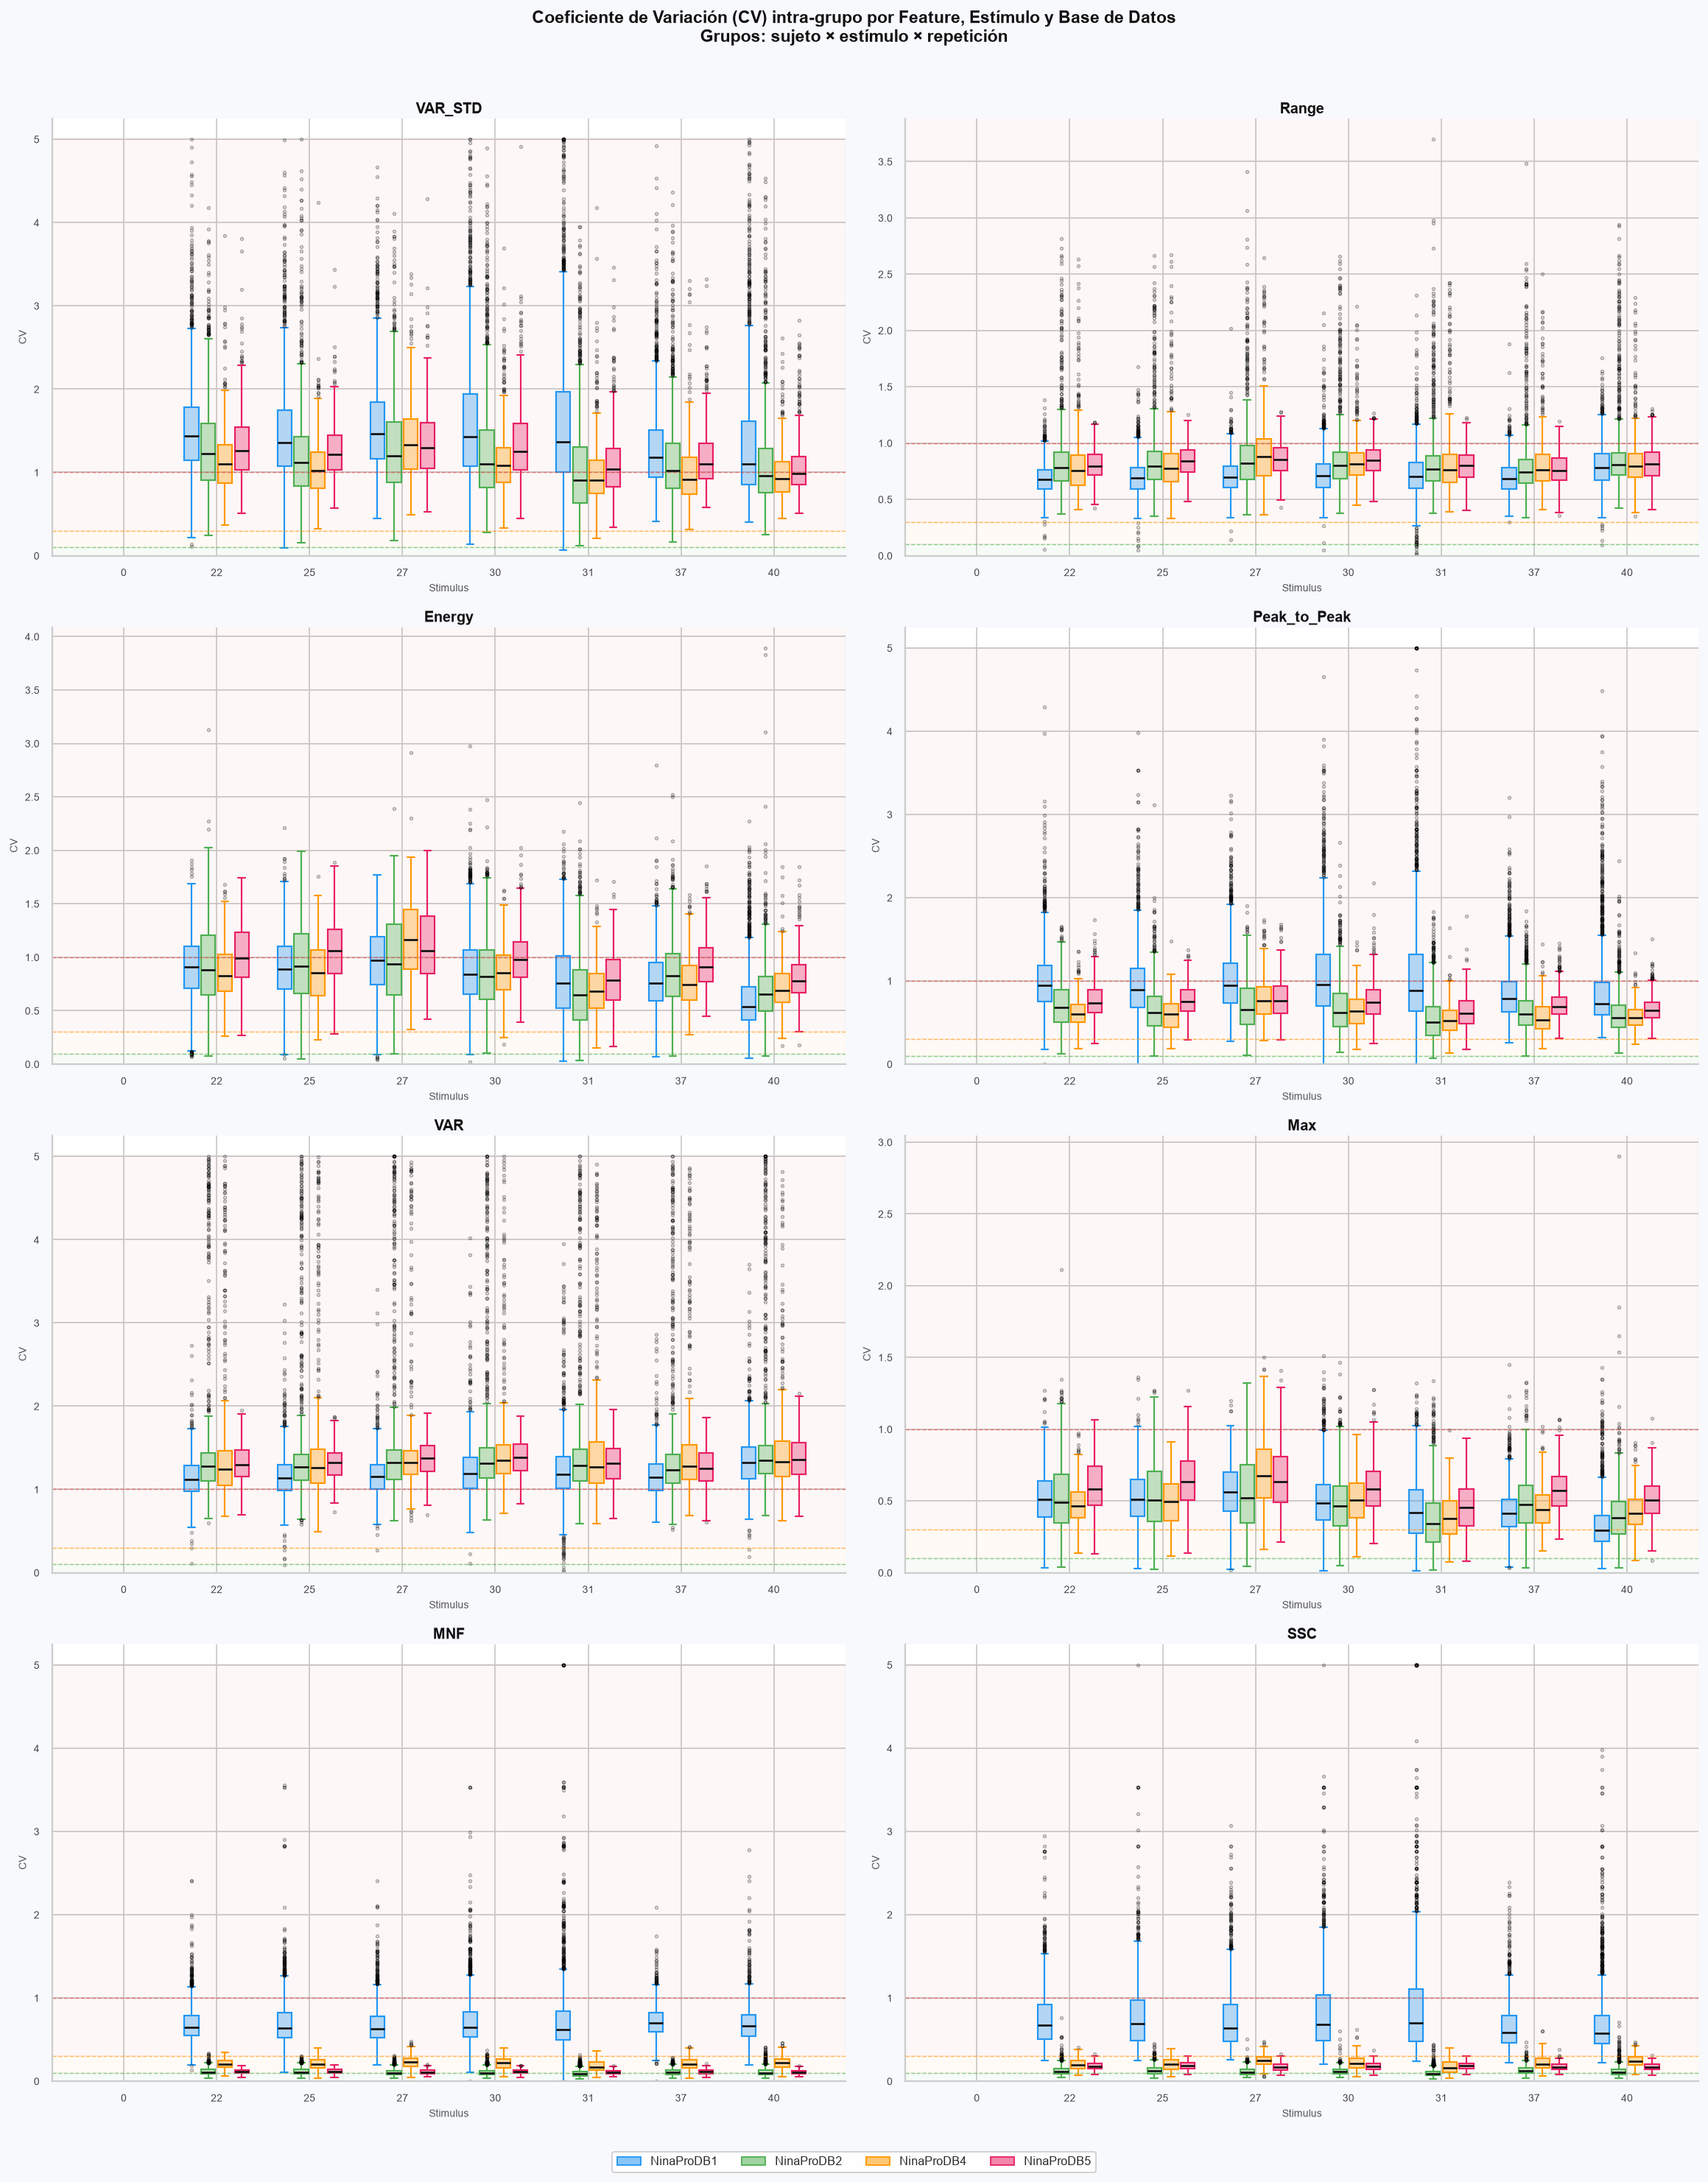

In [9]:
databases = sorted(df_intact['origin_db'].unique())
#stimuli   = sorted([s for s in df_intact['stimulus'].unique() if s != 0])
stimuli = sorted(df_intact['stimulus'].unique())
n_db      = len(databases)

DB_COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
db_color_map = dict(zip(databases, DB_COLORS))

# df con los resultados
df_cv_plot = df_cv[df_cv['stimulus'] != 0].copy()
df_cv_plot['cv'] = df_cv_plot['cv'].clip(upper=5)

n_cols = 2
n_rows = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 22), dpi=130)
fig.patch.set_facecolor('#F7F9FC')
axes = axes.flatten()

stim_labels = [str(s) for s in stimuli]
x_pos       = np.arange(len(stimuli))
width       = 0.18
offsets     = np.linspace(-(n_db-1)/2, (n_db-1)/2, n_db) * width

for ax_i, feature in enumerate(features):
    ax = axes[ax_i]
    ax.set_facecolor('#FFFFFF')
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#CCCCCC')
    ax.tick_params(colors='#444444', labelsize=8)

    df_feat = df_cv_plot[df_cv_plot['feature'] == feature]

    for d_i, db in enumerate(databases):
        df_db = df_feat[df_feat['origin_db'] == db]
        color = db_color_map[db]

        data_per_stim = [
            df_db[df_db['stimulus'] == s]['cv'].dropna().values
            for s in stimuli
        ]

        positions = x_pos + offsets[d_i]

        ax.boxplot(data_per_stim,
                   positions=positions,
                   widths=width * 0.85,
                   patch_artist=True,
                   showfliers=True,
                   flierprops=dict(marker='o', markersize=2,
                                   alpha=0.3, color=color),
                   medianprops=dict(color='#111111', linewidth=1.5),
                   whiskerprops=dict(color=color, linewidth=1.2),
                   capprops=dict(color=color, linewidth=1.2),
                   boxprops=dict(facecolor=color + '55',
                                 edgecolor=color, linewidth=1.2))

    ax.axhline(0.10, color='#4CAF50', lw=0.8, ls='--', alpha=0.6)
    ax.axhline(0.30, color='#FF9800', lw=0.8, ls='--', alpha=0.6)
    ax.axhline(1.00, color='#E53935', lw=0.8, ls='--', alpha=0.6)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(stim_labels, fontsize=8)
    ax.set_title(feature, fontsize=11, fontweight='bold',
                 color='#111111', pad=4)
    ax.set_ylabel('CV', fontsize=8, color='#555555')
    ax.set_xlabel('Stimulus', fontsize=8, color='#555555')
    ax.set_ylim(bottom=0)

    ax.axhspan(0,    0.10, alpha=0.04, color='#4CAF50')
    ax.axhspan(0.10, 0.30, alpha=0.04, color='#FF9800')
    ax.axhspan(0.30, 5.00, alpha=0.04, color='#E53935')

# ── Leyenda ───
db_patches = [mpatches.Patch(facecolor=db_color_map[db] + '88',
                              edgecolor=db_color_map[db],
                              label=db)
              for db in databases]

fig.legend(handles=db_patches,
           loc='lower center', bbox_to_anchor=(0.5, -0.02),
           ncol=n_db + 3, fontsize=9, frameon=True,
           framealpha=0.95, edgecolor='#CCCCCC')

fig.suptitle(
    'Coeficiente de Variación (CV) intra-grupo por Feature, Estímulo y Base de Datos\n'
    'Grupos: sujeto × estímulo × repetición',
    fontsize=13, fontweight='bold', color='#111111', y=1.01
)

plt.tight_layout()
plt.savefig('../figures/CV_analysis_boxplot.pdf', bbox_inches='tight', dpi=150)
plt.show()

### Función graficar todas las repeticiones para cada sujeto

In [10]:
def plot_scatter_ventanas(df_intact, features, subject,
                          db=None,
                          smooth_window=3,
                          save_path='../figures/'):
    """
    Genera imágenes PNG por estímulo × grupo de features para un sujeto.

    Parámetros:
    -----------
    df_intact     : DataFrame con las features por ventana
    features      : list → ['Energy', 'MAV', ...]
    subject       : int  → sujeto a graficar
    db            : str  → base de datos específica (None = todas)
    smooth_window : int  → ventana de suavizado (3 = suave, 1 = sin suavizar)
    save_path     : str  → carpeta raíz de destino
    """

    features_ok = [f for f in features
                   if any(f'_{f}' in col for col in df_intact.columns)]

    feat_groups = [features_ok[:4], features_ok[4:8]]
    feat_groups = [g for g in feat_groups if g]

    #stimuli = sorted([s for s in df_intact['stimulus'].unique() if s != 0])
    stimuli = sorted(df_intact['stimulus'].unique())

    # ── Filtrar DBs ────
    databases = sorted(df_intact['origin_db'].unique())
    if db is not None:
        if db not in databases:
            print(f"DB '{db}' no encontrada. Disponibles: {databases}")
            return
        databases = [db]

    for db_ in databases:
        df_sub = df_intact[
            (df_intact['origin_db'] == db_) &
            (df_intact['subject']   == subject)
        ]

        sub_path = os.path.join(save_path, db_, f'S{subject:02d}')
        os.makedirs(sub_path, exist_ok=True)

        reps          = sorted(df_sub[df_sub['stimulus'] != 0]['repetition'].unique())
        n_rep         = len(reps)
        REP_COLORS    = plt.cm.tab10(np.linspace(0, 0.9, n_rep))
        rep_color_map = dict(zip(reps, REP_COLORS))

        rep_handles = [
            Line2D([0], [0], color=rep_color_map[rep],
                   lw=1.5, label=f'Rep {rep}')
            for rep in reps
        ]

        for stimulus in stimuli:
            df_stim = df_sub[df_sub['stimulus'] == stimulus]
            if df_stim.empty:
                continue

            for g_i, feat_group in enumerate(feat_groups):
                n_feat = len(feat_group)
                n_ch   = 8

                fig, axes = plt.subplots(n_feat, n_ch,
                                         figsize=(n_ch * 2.0, n_feat * 1.8),
                                         dpi=80, sharey='row')
                fig.patch.set_facecolor('#F7F9FC')

                if n_feat == 1:
                    axes = axes[np.newaxis, :]

                for r, feature in enumerate(feat_group):
                    feat_cols = [f'Channel {ch}_{feature}'
                                 for ch in range(1, 9)
                                 if f'Channel {ch}_{feature}' in df_stim.columns]

                    for c, col in enumerate(feat_cols):
                        ax = axes[r, c]
                        ax.set_facecolor('#FFFFFF')
                        ax.spines[['top', 'right']].set_visible(False)
                        ax.spines[['left', 'bottom']].set_color('#DDDDDD')
                        ax.tick_params(labelsize=5, colors='#555555')

                        for rep in reps:
                            data = df_stim[df_stim['repetition'] == rep][col].dropna().values
                            if len(data) == 0:
                                continue

                            # Suavizado
                            data_smooth = (pd.Series(data)
                                           .rolling(smooth_window,
                                                    center=True,
                                                    min_periods=1)
                                           .mean()
                                           .values)

                            color = rep_color_map[rep]
                            ax.plot(np.arange(len(data_smooth)), data_smooth,
                                    color=color, lw=1.2, alpha=0.75, zorder=2)
                            ax.axhline(np.mean(data), color=color,
                                       lw=0.8, ls='--', alpha=0.5, zorder=3)

                        if c == 0:
                            ax.set_ylabel(feature, fontsize=7,
                                          fontweight='bold', color='#222222')
                        if r == 0:
                            ax.set_title(f'Ch {c + 1}', fontsize=8,
                                         fontweight='bold', color='#222222')
                        if r == n_feat - 1:
                            ax.set_xlabel('Ventana', fontsize=6, color='#555555')

                fig.legend(handles=rep_handles,
                           loc='lower center',
                           bbox_to_anchor=(0.5, -0.04),
                           ncol=min(n_rep, 10),
                           fontsize=8, frameon=True,
                           framealpha=0.95, edgecolor='#CCCCCC',
                           title='Repetición', title_fontsize=9)

                fig.suptitle(
                    f'S{subject}  ·  {db_}  ·  Estímulo {stimulus}  ·  '
                    f'{", ".join(feat_group)}',
                    fontsize=10, fontweight='bold',
                    color='#111111', y=1.01
                )

                fig.subplots_adjust(hspace=0.4, wspace=0.3)

                fname = f'S{subject:02d}_Stim{stimulus}_feat{g_i*4+1}-{g_i*4+n_feat}.png'
                fig.savefig(os.path.join(sub_path, fname),
                            bbox_inches='tight', dpi=300)
                plt.close(fig)
                gc.collect()

        print(f"S{subject:02d} · {db_} → {sub_path}")

In [11]:
# Solo SX en DBX
plot_scatter_ventanas(df_intact, features=features, subject=1, db='NinaProDB1')

# # S1 en todas las DBs
# plot_scatter_ventanas(df_intact, features=features,subject=1)

# # Todos los sujetos en DB1
# for s in sorted(df_intact['subject'].unique()):
#     plot_scatter_ventanas(df_intact, features=features,
#                           subject=s, db='NinaProDB1')

# # Todos los sujetos en todas las DBs
# for s in sorted(df_intact['subject'].unique()):
#     plot_scatter_ventanas(df_intact, features=features, subject=s)

S01 · NinaProDB1 → ../figures/NinaProDB1\S01


### Función para graficar el promedio de las repeticiones

In [12]:
def plot_mean_repeticiones(df_intact, features, subject,
                           db=None,
                           smooth_window=3,
                           save_path='../figures/'):
    """
    Genera imágenes PNG con:
    - Línea azul  : promedio de todas las repeticiones
    - Línea roja  : máximo real por ventana
    - Sombra azul : rango real (min–max)
    - Texto AUC   : área bajo la curva para mean y max

    Parámetros:
    -----------
    df_intact     : DataFrame con las features por ventana
    features      : list → ['Energy', 'MAV', ...]
    subject       : int  → sujeto a graficar
    db            : str  → base de datos específica (None = todas)
    smooth_window : int  → ventana de suavizado
    save_path     : str  → carpeta raíz de destino
    """

    features_ok = [f for f in features
                   if any(f'_{f}' in col for col in df_intact.columns)]

    feat_groups = [features_ok[:4], features_ok[4:8]]
    feat_groups = [g for g in feat_groups if g]

    stimuli = sorted([s for s in df_intact['stimulus'].unique() if s != 0])

    # ── Filtrar DBs ──────────────────────
    databases = sorted(df_intact['origin_db'].unique())
    if db is not None:
        if db not in databases:
            print(f"DB '{db}' no encontrada. Disponibles: {databases}")
            return
        databases = [db]

    for db_ in databases:
        df_sub = df_intact[
            (df_intact['origin_db'] == db_) &
            (df_intact['subject']   == subject)
        ]

        sub_path = os.path.join(save_path, db_, f'S{subject:02d}')
        os.makedirs(sub_path, exist_ok=True)

        reps  = sorted(df_sub[df_sub['stimulus'] != 0]['repetition'].unique())
        n_rep = len(reps)

        for stimulus in stimuli:
            df_stim = df_sub[df_sub['stimulus'] == stimulus]
            if df_stim.empty:
                continue

            for g_i, feat_group in enumerate(feat_groups):
                n_feat = len(feat_group)
                n_ch   = 8

                fig, axes = plt.subplots(n_feat, n_ch,
                                         figsize=(n_ch * 2.0, n_feat * 1.8),
                                         dpi=80, sharey='row')
                fig.patch.set_facecolor('#F7F9FC')

                if n_feat == 1:
                    axes = axes[np.newaxis, :]

                for r, feature in enumerate(feat_group):
                    feat_cols = [f'Channel {ch}_{feature}'
                                 for ch in range(1, 9)
                                 if f'Channel {ch}_{feature}' in df_stim.columns]

                    for c, col in enumerate(feat_cols):
                        ax = axes[r, c]
                        ax.set_facecolor('#FFFFFF')
                        ax.spines[['top', 'right']].set_visible(False)
                        ax.spines[['left', 'bottom']].set_color('#DDDDDD')
                        ax.tick_params(labelsize=5, colors='#555555')

                        # Alinear repeticiones
                        rep_arrays = []
                        for rep in reps:
                            data = df_stim[df_stim['repetition'] == rep][col].dropna().values
                            if len(data) > 0:
                                rep_arrays.append(data)

                        if not rep_arrays:
                            continue

                        min_len    = min(len(a) for a in rep_arrays)
                        rep_matrix = np.array([a[:min_len] for a in rep_arrays])

                        mean_vals = rep_matrix.mean(axis=0)
                        min_vals  = rep_matrix.min(axis=0)
                        max_vals  = rep_matrix.max(axis=0)

                        # Suavizado
                        def smooth(arr):
                            return (pd.Series(arr)
                                    .rolling(smooth_window,
                                             center=True,
                                             min_periods=1)
                                    .mean()
                                    .values)

                        mean_smooth = smooth(mean_vals)
                        min_smooth  = smooth(min_vals)
                        max_smooth  = smooth(max_vals)

                        x = np.arange(len(mean_smooth))

                        # AUC con regla del trapecio
                        auc_mean = np.trapz(mean_smooth, x)
                        auc_max  = np.trapz(max_smooth, x)

                        # Sombra rango real
                        ax.fill_between(x, min_smooth, max_smooth,
                                        color='#2196F3', alpha=0.12,
                                        zorder=1)

                        # Línea media
                        ax.plot(x, mean_smooth,
                                color='#1565C0', lw=1.5,
                                alpha=0.90, zorder=2,
                                label='Mean')

                        # Línea máximo
                        ax.plot(x, max_smooth,
                                color='#E53935', lw=1.2,
                                alpha=0.85, zorder=3,
                                ls='--', label='Max')

                        # AUC en esquina superior
                        ax.text(0.98, 0.97,
                                f'AUC\nμ={auc_mean:.1f}\nmax={auc_max:.1f}',
                                transform=ax.transAxes,
                                fontsize=4.5,
                                va='top', ha='right',
                                color='#333333',
                                bbox=dict(boxstyle='round,pad=0.2',
                                          facecolor='white',
                                          edgecolor='#CCCCCC',
                                          alpha=0.8))

                        if c == 0:
                            ax.set_ylabel(feature, fontsize=7,
                                          fontweight='bold', color='#222222')
                        if r == 0:
                            ax.set_title(f'Ch {c + 1}', fontsize=8,
                                         fontweight='bold', color='#222222')
                        if r == n_feat - 1:
                            ax.set_xlabel('Ventana', fontsize=6,
                                          color='#555555')

                # Leyenda
                legend_handles = [
                    Line2D([0], [0], color='#1565C0', lw=1.5,
                           label=f'Media ({n_rep} reps)'),
                    Line2D([0], [0], color='#E53935', lw=1.2,
                           ls='--', label='Máximo real'),
                    mpatches.Patch(facecolor='#2196F3', alpha=0.25,
                                   edgecolor='#2196F3',
                                   label='Rango real (min–max)'),
                ]
                fig.legend(handles=legend_handles,
                           loc='lower center',
                           bbox_to_anchor=(0.5, -0.04),
                           ncol=3, fontsize=9, frameon=True,
                           framealpha=0.95, edgecolor='#CCCCCC')

                fig.suptitle(
                    f'S{subject}  ·  {db_}  ·  Estímulo {stimulus}  ·  '
                    f'{", ".join(feat_group)}  ·  {n_rep} repeticiones',
                    fontsize=10, fontweight='bold',
                    color='#111111', y=1.01
                )

                fig.subplots_adjust(hspace=0.4, wspace=0.3)

                fname = f'S{subject:02d}_Stim{stimulus}_feat{g_i*4+1}-{g_i*4+n_feat}_mean.png'
                fig.savefig(os.path.join(sub_path, fname),
                            bbox_inches='tight', dpi=300)
                plt.close(fig)
                gc.collect()

        print(f"S{subject:02d} · {db_} → {sub_path}")

In [13]:
plot_mean_repeticiones(df_intact, features=features,
                       subject=1, db='NinaProDB1')

S01 · NinaProDB1 → ../figures/NinaProDB1\S01


In [14]:
df_intact.head(30)

,subject,stimulus,origin_db,repetition,Channel 1_VAR_STD,Channel 1_Range,Channel 1_Energy,Channel 1_Peak_to_Peak,Channel 1_VAR,Channel 1_Max,...,Channel 7_MNF,Channel 7_SSC,Channel 8_VAR_STD,Channel 8_Range,Channel 8_Energy,Channel 8_Peak_to_Peak,Channel 8_VAR,Channel 8_Max,Channel 8_MNF,Channel 8_SSC
0,1,22,NinaProDB1,1,0.001033,0.040034,9.149888,0.0611,1.477702e-04,0.695626,...,5.961012,2,0.000932,0.071187,7.951489,0.0317,0.000467,0.665271,3.388667,4
1,1,22,NinaProDB1,1,0.000046,0.048506,7.932059,0.0122,2.169982e-04,0.653253,...,5.172572,4,0.000950,0.076264,6.109683,0.0342,0.000537,0.590169,4.875131,3
2,1,22,NinaProDB1,1,0.000000,0.055218,6.613127,0.0000,2.813390e-04,0.601996,...,8.095824,3,0.000486,0.072910,4.477883,0.0244,0.000493,0.509871,3.115516,3
3,1,22,NinaProDB1,1,0.000048,0.058243,5.303784,0.0098,3.132917e-04,0.543751,...,11.251693,4,0.005782,0.054283,3.274406,0.1123,0.000275,0.433467,7.660429,0
4,1,22,NinaProDB1,1,0.000004,0.055119,4.134773,0.0025,2.810018e-04,0.482461,...,3.711943,4,0.002377,0.019837,2.653012,0.0537,0.000039,0.377117,2.589679,4
5,1,22,NinaProDB1,1,0.000046,0.043684,3.229690,0.0098,1.770469e-04,0.424665,...,3.950488,2,0.002755,0.022272,2.670651,0.0512,0.000049,0.379607,3.427735,4
6,1,22,NinaProDB1,1,0.000160,0.023916,2.672116,0.0245,5.377954e-05,0.379140,...,10.654974,4,0.015981,0.057321,3.343680,0.1880,0.000307,0.439152,9.079539,1
7,1,22,NinaProDB1,1,0.008077,0.003245,2.492335,0.1319,9.742220e-07,0.355155,...,5.442071,6,0.120545,0.071460,4.586641,0.4052,0.000475,0.514219,4.342650,1
8,1,22,NinaProDB1,1,0.006998,0.023225,2.679739,0.0684,5.072735e-05,0.379052,...,7.959532,1,0.079875,0.061419,6.059224,0.2857,0.000350,0.579318,3.258679,4
9,1,22,NinaProDB1,1,0.039785,0.037776,3.185912,0.2172,1.326119e-04,0.418522,...,1.830359,3,0.034738,0.036814,7.260615,0.1733,0.000126,0.618780,2.803425,4


## Creación base de datos - mean/max ---> AUC

### AUC

In [18]:
def calcular_auc(df_intact, features, agg_func='mean', smooth_window=3):
    """
    Calcula el AUC (área bajo la curva) por sujeto × DB × estímulo.

    Para cada grupo (db × subject × stimulus):
        1. Toma todas las repeticiones
        2. Alinea las ventanas al mínimo largo
        3. Aplica agg_func sobre las repeticiones (eje=repeticiones)
        4. Suaviza la curva resultante
        5. Calcula el AUC con la regla del trapecio

    El resultado es UNA fila por db × subject × stimulus,
    con una columna por cada combinación feature × canal.

    Estructura del DataFrame resultante:
    ------------------------------------
    | origin_db | subject | stimulus | Channel 1_Energy | Channel 2_Energy | ... | Channel 8_IEMG |
    |-----------|---------|----------|------------------|------------------|-----|----------------|
    | NinaProDB1|    1    |    22    |     1243.7       |      987.3       | ... |     456.1      |
    | NinaProDB1|    1    |    25    |     1100.2       |      876.4       | ... |     389.7      |

    Filas    : n_DBs × n_subjects × n_stimuli  (ej. 4 × 40 × 7 = 1,120)
    Columnas : 3 (metadata) + n_features × n_canales  (ej. 3 + 8×8 = 67)

    Parámetros:
    -----------
    df_intact     : DataFrame con las features por ventana
    features      : list  → ['Energy', 'MAV', 'RMS', ...]
    agg_func      : str   → función de agregación sobre repeticiones:
                            'mean'   → promedio
                            'max'    → máximo
                            'min'    → mínimo
                            'median' → mediana
                            'p75'    → percentil 75
                            'p25'    → percentil 25
    smooth_window : int   → ventana de suavizado (rolling mean, default=3)

    Retorna:
    --------
    df_auc : DataFrame con AUC por db × subject × stimulus × (feature × canal)
    """

    func_map = {
        'mean'  : lambda x: np.mean(x,   axis=0),
        'max'   : lambda x: np.max(x,    axis=0),
        'min'   : lambda x: np.min(x,    axis=0),
        'median': lambda x: np.median(x, axis=0),
        'p75'   : lambda x: np.percentile(x, 75, axis=0),
        'p25'   : lambda x: np.percentile(x, 25, axis=0),
    }

    if agg_func not in func_map:
        print(f" Opciones válidas: {list(func_map.keys())}")
        return None

    func = func_map[agg_func]

    features_ok = [f for f in features
                   if any(f'_{f}' in col for col in df_intact.columns)]
    if not features_ok:
        print(" Ninguna feature encontrada")
        return None

    # stimuli   = sorted([s for s in df_intact['stimulus'].unique() if s != 0])
    stimuli = sorted(df_intact['stimulus'].unique())
    databases = sorted(df_intact['origin_db'].unique())
    subjects  = sorted(df_intact['subject'].unique())

    feat_cols = [f'Channel {ch}_{feat}'
                 for feat in features_ok
                 for ch in range(1, 9)
                 if f'Channel {ch}_{feat}' in df_intact.columns]

    def smooth(arr):
        return (pd.Series(arr)
                .rolling(smooth_window, center=True, min_periods=1)
                .mean().values)

    rows = []

    for db in databases:
        for subject in subjects:
            df_sub = df_intact[
                (df_intact['origin_db'] == db) &
                (df_intact['subject']   == subject)
            ]
            if df_sub.empty:
                continue

            reps = sorted(df_sub[df_sub['stimulus'] != 0]['repetition'].unique())

            for stimulus in stimuli:
                df_stim = df_sub[df_sub['stimulus'] == stimulus]
                if df_stim.empty:
                    continue

                row = {
                    'origin_db': db,
                    'subject'  : subject,
                    'stimulus' : stimulus,
                }

                for col in feat_cols:
                    if col not in df_stim.columns:
                        row[col] = np.nan
                        continue

                    rep_arrays = []
                    for rep in reps:
                        data = df_stim[df_stim['repetition'] == rep][col].dropna().values
                        if len(data) > 0:
                            rep_arrays.append(data)

                    if not rep_arrays:
                        row[col] = np.nan
                        continue

                    min_len    = min(len(a) for a in rep_arrays)
                    rep_matrix = np.array([a[:min_len] for a in rep_arrays])
                    agg_smooth = smooth(func(rep_matrix))
                    row[col]   = np.trapz(agg_smooth, np.arange(min_len))

                rows.append(row)

            print(f"   S{subject:02d} · {db}")

    df_auc = pd.DataFrame(rows)
    print(f"\n df_auc_{agg_func} shape: {df_auc.shape}")
    print(f"  Filas    : {df_auc.shape[0]}  (db × subject × stimulus)")
    print(f"  Columnas : {df_auc.shape[1]}  (3 metadata + {len(feat_cols)} features×canales)")
    return df_auc

#### Max

In [ ]:
df_auc_max    = calcular_auc(df_intact, features, agg_func='max')
# Guardar df_auc originales (sin normalizar)
df_auc_max.to_excel('../resultados/df_auc_max.xlsx',   index=False)

   S01 · NinaProDB1
   S02 · NinaProDB1
   S03 · NinaProDB1
   S04 · NinaProDB1
   S05 · NinaProDB1
   S06 · NinaProDB1
   S07 · NinaProDB1
   S08 · NinaProDB1
   S09 · NinaProDB1
   S10 · NinaProDB1
   S11 · NinaProDB1
   S12 · NinaProDB1
   S13 · NinaProDB1
   S14 · NinaProDB1
   S15 · NinaProDB1
   S16 · NinaProDB1
   S17 · NinaProDB1
   S18 · NinaProDB1
   S19 · NinaProDB1
   S20 · NinaProDB1
   S21 · NinaProDB1
   S22 · NinaProDB1
   S23 · NinaProDB1
   S24 · NinaProDB1
   S25 · NinaProDB1
   S26 · NinaProDB1
   S27 · NinaProDB1
   S01 · NinaProDB2
   S02 · NinaProDB2
   S03 · NinaProDB2
   S04 · NinaProDB2
   S05 · NinaProDB2


#### Mean

In [ ]:
df_auc_mean   = calcular_auc(df_intact, features, agg_func='mean')
# Guardar df_auc originales (sin normalizar)
df_auc_mean.to_excel('../resultados/df_auc_mean.xlsx', index=False)
# df_auc_median = calcular_auc(df_intact, features, agg_func='median')
# df_auc_p75    = calcular_auc(df_intact, features, agg_func='p75')

   S01 · NinaProDB1
   S02 · NinaProDB1
   S03 · NinaProDB1
   S04 · NinaProDB1
   S05 · NinaProDB1
   S06 · NinaProDB1
   S07 · NinaProDB1
   S08 · NinaProDB1
   S09 · NinaProDB1
   S10 · NinaProDB1
   S11 · NinaProDB1
   S12 · NinaProDB1
   S13 · NinaProDB1
   S14 · NinaProDB1
   S15 · NinaProDB1
   S16 · NinaProDB1
   S17 · NinaProDB1
   S18 · NinaProDB1
   S19 · NinaProDB1
   S20 · NinaProDB1
   S21 · NinaProDB1
   S22 · NinaProDB1
   S23 · NinaProDB1
   S24 · NinaProDB1
   S25 · NinaProDB1
   S26 · NinaProDB1
   S27 · NinaProDB1
   S01 · NinaProDB2
   S02 · NinaProDB2
   S03 · NinaProDB2
   S04 · NinaProDB2
   S05 · NinaProDB2
   S06 · NinaProDB2
   S07 · NinaProDB2
   S08 · NinaProDB2
   S09 · NinaProDB2
   S10 · NinaProDB2
   S11 · NinaProDB2
   S12 · NinaProDB2
   S13 · NinaProDB2
   S14 · NinaProDB2
   S15 · NinaProDB2
   S16 · NinaProDB2
   S17 · NinaProDB2
   S18 · NinaProDB2
   S19 · NinaProDB2
   S20 · NinaProDB2
   S21 · NinaProDB2
   S22 · NinaProDB2
   S23 · NinaProDB2


In [ ]:
df_auc_mean.head(10)

,origin_db,subject,stimulus,Channel 1_VAR_STD,Channel 2_VAR_STD,Channel 3_VAR_STD,Channel 4_VAR_STD,Channel 5_VAR_STD,Channel 6_VAR_STD,Channel 7_VAR_STD,...,Channel 7_MNF,Channel 8_MNF,Channel 1_SSC,Channel 2_SSC,Channel 3_SSC,Channel 4_SSC,Channel 5_SSC,Channel 6_SSC,Channel 7_SSC,Channel 8_SSC
0,NinaProDB1,1,22,0.608646,1.797925,1.788122,0.217035,0.014690,0.050668,1.775730,...,121.928070,86.762268,73.775000,58.391667,85.508333,40.250000,44.066667,49.408333,88.775000,90.408333
1,NinaProDB1,1,25,0.731750,0.609576,1.010855,0.320152,0.016626,0.026118,5.284745,...,116.433601,81.825697,67.208333,46.700000,67.775000,60.733333,34.958333,34.900000,95.450000,100.016667
2,NinaProDB1,1,27,1.990391,0.936693,1.440167,0.092730,0.014959,0.124602,2.443427,...,119.168814,78.168460,90.391667,68.083333,72.508333,41.483333,41.900000,49.358333,96.100000,100.675000
3,NinaProDB1,1,30,5.515111,5.975873,3.904813,0.514608,0.036709,0.035766,4.499380,...,113.145069,82.191062,84.983333,57.891667,66.583333,35.475000,50.291667,51.191667,99.508333,99.050000
4,NinaProDB1,1,31,0.052204,0.264928,1.153939,0.027451,0.028336,0.004607,0.267303,...,98.924799,79.864296,60.583333,40.091667,63.250000,22.316667,55.875000,31.891667,90.600000,104.325000
5,NinaProDB1,1,37,1.487167,2.997959,2.633301,0.138350,0.016632,0.026465,3.920891,...,92.682723,62.861022,102.916667,86.533333,97.975000,50.983333,41.008333,49.116667,116.125000,109.133333
6,NinaProDB1,1,40,0.942206,1.371640,0.361698,0.052621,0.045568,0.014923,3.239635,...,106.482256,78.299362,101.083333,88.200000,59.733333,31.275000,59.750000,42.983333,102.725000,123.400000
7,NinaProDB1,2,22,1.946780,2.254924,0.780461,1.080688,0.131727,0.012522,0.422335,...,130.392994,94.059982,109.800000,101.441667,82.283333,64.333333,45.350000,27.766667,61.483333,101.008333
8,NinaProDB1,2,25,4.631224,1.302119,0.614485,0.138387,0.343464,0.011241,0.070504,...,150.414976,85.661543,104.883333,99.858333,78.833333,40.316667,55.775000,22.775000,50.466667,107.091667
9,NinaProDB1,2,27,3.351951,4.217649,0.774635,1.545133,0.074970,0.015127,0.717282,...,131.741159,84.754442,111.591667,116.358333,88.333333,70.050000,44.458333,30.858333,63.383333,110.116667


In [ ]:
df_auc_max.head(10)

,origin_db,subject,stimulus,Channel 1_VAR_STD,Channel 2_VAR_STD,Channel 3_VAR_STD,Channel 4_VAR_STD,Channel 5_VAR_STD,Channel 6_VAR_STD,Channel 7_VAR_STD,...,Channel 7_MNF,Channel 8_MNF,Channel 1_SSC,Channel 2_SSC,Channel 3_SSC,Channel 4_SSC,Channel 5_SSC,Channel 6_SSC,Channel 7_SSC,Channel 8_SSC
0,NinaProDB1,1,22,1.556622,8.491342,4.807763,0.657234,0.052948,0.126834,6.225271,...,216.338318,153.986437,139.166667,118.000000,143.750000,92.916667,93.333333,97.500000,158.416667,161.583333
1,NinaProDB1,1,25,2.335566,1.654429,2.529078,1.077355,0.065492,0.079775,14.299958,...,196.925029,153.904745,137.333333,93.000000,124.750000,111.333333,81.166667,89.000000,163.166667,168.916667
2,NinaProDB1,1,27,5.408909,3.989522,8.206502,0.474338,0.058332,0.503866,8.516195,...,208.520234,150.899472,145.916667,133.916667,142.500000,98.000000,97.083333,107.833333,157.500000,151.916667
3,NinaProDB1,1,30,18.827876,35.048381,17.412131,3.460524,0.128043,0.105301,15.995140,...,206.973507,148.802810,151.416667,122.916667,140.083333,91.833333,112.083333,101.500000,168.666667,158.916667
4,NinaProDB1,1,31,0.186208,1.404981,6.669579,0.207704,0.078409,0.018098,1.257786,...,170.885424,135.944500,117.416667,102.916667,126.833333,68.416667,104.166667,84.250000,146.916667,161.000000
5,NinaProDB1,1,37,4.698855,11.278910,8.322564,0.551235,0.086173,0.099120,13.222737,...,185.293766,135.865234,168.583333,156.250000,155.333333,127.500000,108.000000,106.750000,183.416667,176.666667
6,NinaProDB1,1,40,2.684434,4.775975,2.128008,0.281541,0.133125,0.058017,9.484576,...,198.059376,151.633808,166.666667,153.916667,113.416667,85.500000,120.000000,100.166667,164.500000,187.000000
7,NinaProDB1,2,22,6.202012,5.600629,3.404330,4.016881,0.735533,0.044318,1.744201,...,245.010358,167.765594,181.833333,170.250000,145.666667,121.000000,103.333333,78.750000,123.250000,178.083333
8,NinaProDB1,2,25,10.665631,3.412468,2.115999,0.621229,1.153662,0.038218,0.221915,...,268.263986,160.716497,167.333333,175.833333,145.500000,101.083333,122.583333,63.833333,114.000000,174.083333
9,NinaProDB1,2,27,10.596254,11.588345,2.127295,7.790040,0.367460,0.054526,2.202524,...,238.560096,166.363347,182.333333,184.083333,160.583333,144.250000,101.416667,81.166667,127.833333,176.083333


Graficas

In [ ]:
def plot_auc_por_canal(df_auc, features, agg_func='mean',
                       save_path='../figures/AUC/'):
    """
    Boxplot + puntos por estímulo (eje X) y AUC normalizado (eje Y).
    Normalización Min-Max por feature × DB (solo para visualizar).
    Cada DB queda en [0-1] → comparables entre DBs.
    Colores = DB. Una figura por feature, con 8 subplots (uno por canal).

    Parámetros:
    -----------
    df_auc    : DataFrame resultado de calcular_auc()
                Estructura: origin_db | subject | stimulus | Channel 1_Energy | ...
    features  : list → ['Energy', 'MAV', ...]
    agg_func  : str  → etiqueta para el título y nombre del archivo
    save_path : str  → carpeta de destino
    """
    import os

    os.makedirs(save_path, exist_ok=True)

    databases = sorted(df_auc['origin_db'].unique())
    stimuli   = sorted(df_auc['stimulus'].unique())
    n_db      = len(databases)
    n_stim    = len(stimuli)

    DB_COLORS    = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
    db_color_map = dict(zip(databases, DB_COLORS))

    x_pos   = np.arange(n_stim)
    width   = 0.18
    offsets = np.linspace(-(n_db - 1) / 2, (n_db - 1) / 2, n_db) * width

    features_ok = [f for f in features
                   if any(f'Channel 1_{f}' in col for col in df_auc.columns)]

    # ── Normalización Min-Max por feature × DB (solo para visualizar) ─────────
    df_plot = df_auc.copy()

    for feature in features_ok:
        feat_cols_norm = [f'Channel {ch}_{feature}'
                          for ch in range(1, 9)
                          if f'Channel {ch}_{feature}' in df_plot.columns]
        for db in databases:
            mask = df_plot['origin_db'] == db
            for col in feat_cols_norm:
                col_min = df_plot.loc[mask, col].min()
                col_max = df_plot.loc[mask, col].max()
                denom   = col_max - col_min
                if denom > 0:
                    df_plot.loc[mask, col] = (df_plot.loc[mask, col] - col_min) / denom
                else:
                    df_plot.loc[mask, col] = 0

    # ── Una figura por feature ────────────────────────────────────────────────
    for feature in features_ok:

        feat_cols = [f'Channel {ch}_{feature}'
                     for ch in range(1, 9)
                     if f'Channel {ch}_{feature}' in df_plot.columns]
        n_ch = len(feat_cols)

        fig, axes = plt.subplots(2, 4,
                                 figsize=(4 * 4, 2 * 3.5),
                                 dpi=90, sharey=True)
        fig.patch.set_facecolor('#F7F9FC')
        axes = axes.flatten()

        for ch_i, col in enumerate(feat_cols):
            ax     = axes[ch_i]
            ch_num = col.split('_')[0]

            ax.set_facecolor('#FFFFFF')
            ax.spines[['top', 'right']].set_visible(False)
            ax.spines[['left', 'bottom']].set_color('#DDDDDD')
            ax.tick_params(labelsize=7, colors='#555555')
            ax.set_ylim(-0.05, 1.05)

            for d_i, db in enumerate(databases):
                df_db = df_plot[df_plot['origin_db'] == db]
                color = db_color_map[db]
                pos   = x_pos + offsets[d_i]

                data_per_stim = [
                    df_db[df_db['stimulus'] == s][col].dropna().values
                    for s in stimuli
                ]

                # Boxplot
                ax.boxplot(data_per_stim,
                           positions=pos,
                           widths=width * 0.85,
                           patch_artist=True,
                           showfliers=False,
                           medianprops=dict(color='#111111', linewidth=1.5),
                           whiskerprops=dict(color=color, linewidth=1.0),
                           capprops=dict(color=color, linewidth=1.0),
                           boxprops=dict(facecolor=color + '33',
                                         edgecolor=color, linewidth=1.0))

                # Puntos jittered
                for p, data in zip(pos, data_per_stim):
                    if len(data) == 0:
                        continue
                    jitter = np.random.uniform(-0.06, 0.06, size=len(data))
                    ax.scatter(np.full(len(data), p) + jitter, data,
                               color=color, s=12, alpha=0.55,
                               zorder=3, edgecolors='none')

            ax.set_xticks(x_pos)
            ax.set_xticklabels([str(s) for s in stimuli],
                               fontsize=7, rotation=30)
            ax.set_title(ch_num, fontsize=9,
                         fontweight='bold', color='#222222', pad=4)
            ax.set_xlabel('Estímulo', fontsize=7, color='#555555')
            if ch_i % 4 == 0:
                ax.set_ylabel('AUC (norm 0–1)', fontsize=7, color='#555555')

        # Ocultar subplots vacíos
        for i in range(n_ch, len(axes)):
            axes[i].set_visible(False)

        # Leyenda
        db_patches = [mpatches.Patch(facecolor=db_color_map[db] + '66',
                                     edgecolor=db_color_map[db],
                                     label=db)
                      for db in databases]
        fig.legend(handles=db_patches,
                   loc='lower center',
                   bbox_to_anchor=(0.5, -0.03),
                   ncol=n_db, fontsize=9,
                   frameon=True, framealpha=0.95,
                   edgecolor='#CCCCCC',
                   title='Database', title_fontsize=9)

        fig.suptitle(
            f'AUC ({agg_func})  ·  Feature: {feature}  ·  '
            f'Norm Min-Max por DB [0–1]\n'
            f'Eje X = Estímulo  ·  Eje Y = AUC norm  ·  '
            f'Colores = DB  ·  Puntos = sujetos',
            fontsize=12, fontweight='bold',
            color='#111111', y=1.02
        )

        fig.subplots_adjust(hspace=0.45, wspace=0.25)

        fname = f'AUC_{agg_func}_{feature}_por_canal_norm.png'
        fig.savefig(os.path.join(save_path, fname),
                    bbox_inches='tight', dpi=300)
        plt.close(fig)
        print(f"✓ {fname}")

    print("\n✓ Todas las figuras generadas")

In [ ]:
plot_auc_por_canal(df_auc_mean, features,
                   agg_func='mean',
                   save_path='../figures/AUC/')

✓ AUC_mean_VAR_STD_por_canal_norm.png
✓ AUC_mean_Range_por_canal_norm.png
✓ AUC_mean_Energy_por_canal_norm.png
✓ AUC_mean_Peak_to_Peak_por_canal_norm.png
✓ AUC_mean_VAR_por_canal_norm.png
✓ AUC_mean_Max_por_canal_norm.png
✓ AUC_mean_MNF_por_canal_norm.png
✓ AUC_mean_SSC_por_canal_norm.png

✓ Todas las figuras generadas


In [ ]:
plot_auc_por_canal(df_auc_mean, features,
                   agg_func='max',
                   save_path='../figures/AUC/')

✓ AUC_max_VAR_STD_por_canal_norm.png
✓ AUC_max_Range_por_canal_norm.png
✓ AUC_max_Energy_por_canal_norm.png
✓ AUC_max_Peak_to_Peak_por_canal_norm.png
✓ AUC_max_VAR_por_canal_norm.png
✓ AUC_max_Max_por_canal_norm.png
✓ AUC_max_MNF_por_canal_norm.png
✓ AUC_max_SSC_por_canal_norm.png

✓ Todas las figuras generadas


### ventana

In [ ]:
def agregar_ventanas(df_intact, features, agg_func='mean', smooth_window=3):
    """
    Agrega repeticiones por ventana (sin calcular AUC).

    Para cada grupo (db × subject × stimulus):
        1. Toma todas las repeticiones
        2. Alinea las ventanas al mínimo largo
        3. Aplica agg_func sobre las repeticiones (eje=repeticiones)
        4. Suaviza la curva resultante
        5. Devuelve UNA FILA POR VENTANA (no colapsa a escalar)

    Estructura del DataFrame resultante:
    ------------------------------------
    | origin_db | subject | stimulus | window | Channel 1_Energy | ... |
    |-----------|---------|----------|--------|------------------|-----|
    | NinaProDB1|    1    |    22    |   0    |     243.7        | ... |
    | NinaProDB1|    1    |    22    |   1    |     198.3        | ... |
    | NinaProDB1|    1    |    22    |   2    |     312.1        | ... |

    Filas    : n_DBs × n_subjects × n_stimuli × n_ventanas_min
    Columnas : 4 (metadata + window) + n_features × n_canales

    Parámetros:
    -----------
    df_intact     : DataFrame con las features por ventana
    features      : list → ['Energy', 'MAV', 'RMS', ...]
    agg_func      : str  → 'mean' | 'max' | 'min' | 'median' | 'p75' | 'p25'
    smooth_window : int  → ventana de suavizado (rolling mean, default=3)

    Retorna:
    --------
    df_agg : DataFrame con una fila por ventana temporal
    """

    func_map = {
        'mean'  : lambda x: np.mean(x,          axis=0),
        'max'   : lambda x: np.max(x,            axis=0),
        'min'   : lambda x: np.min(x,            axis=0),
        'median': lambda x: np.median(x,         axis=0),
        'p75'   : lambda x: np.percentile(x, 75, axis=0),
        'p25'   : lambda x: np.percentile(x, 25, axis=0),
    }

    if agg_func not in func_map:
        print(f"  Opciones válidas: {list(func_map.keys())}")
        return None

    func = func_map[agg_func]

    features_ok = [f for f in features
                   if any(f'_{f}' in col for col in df_intact.columns)]
    if not features_ok:
        print("  Ninguna feature encontrada")
        return None

    stimuli   = sorted([s for s in df_intact['stimulus'].unique() if s != 0])
    databases = sorted(df_intact['origin_db'].unique())
    subjects  = sorted(df_intact['subject'].unique())

    feat_cols = [f'Channel {ch}_{feat}'
                 for feat in features_ok
                 for ch in range(1, 9)
                 if f'Channel {ch}_{feat}' in df_intact.columns]

    def smooth(arr):
        return (pd.Series(arr)
                .rolling(smooth_window, center=True, min_periods=1)
                .mean().values)

    rows = []

    for db in databases:
        for subject in subjects:
            df_sub = df_intact[
                (df_intact['origin_db'] == db) &
                (df_intact['subject']   == subject)
            ]
            if df_sub.empty:
                continue

            reps = sorted(df_sub[df_sub['stimulus'] != 0]['repetition'].unique())

            for stimulus in stimuli:
                df_stim = df_sub[df_sub['stimulus'] == stimulus]
                if df_stim.empty:
                    continue

                # Construir matriz (repeticiones × ventanas) por columna
                col_curves = {}
                min_len    = None

                for col in feat_cols:
                    if col not in df_stim.columns:
                        col_curves[col] = None
                        continue

                    rep_arrays = []
                    for rep in reps:
                        data = df_stim[df_stim['repetition'] == rep][col].dropna().values
                        if len(data) > 0:
                            rep_arrays.append(data)

                    if not rep_arrays:
                        col_curves[col] = None
                        continue

                    # Alinear al mínimo largo entre repeticiones
                    ml = min(len(a) for a in rep_arrays)
                    if min_len is None or ml < min_len:
                        min_len = ml

                    rep_matrix     = np.array([a[:ml] for a in rep_arrays])
                    col_curves[col] = smooth(func(rep_matrix))  # shape: (ml,)

                if min_len is None:
                    continue

                # Recortar todas las curvas al mismo largo (el menor entre features)
                for w in range(min_len):
                    row = {
                        'origin_db': db,
                        'subject'  : subject,
                        'stimulus' : stimulus,
                        'window'   : w,
                    }
                    for col in feat_cols:
                        curve = col_curves.get(col)
                        row[col] = curve[w] if curve is not None and w < len(curve) else np.nan

                    rows.append(row)

            print(f"   S{subject:02d} · {db}")

    df_agg = pd.DataFrame(rows)
    print(f"\n df_agg_{agg_func} shape: {df_agg.shape}")
    print(f"  Filas    : {df_agg.shape[0]}  (db × subject × stimulus × ventana)")
    print(f"  Columnas : {df_agg.shape[1]}  (4 metadata + {len(feat_cols)} features×canales)")
    return df_agg

In [ ]:
def plot_agg_por_canal(df_agg, features, agg_func='mean',
                       save_path='../figures/AGG/'):
    """
    Curvas temporales (ventana a ventana) por estímulo.
    Una figura por feature × DB, con 8 subplots (uno por canal).

    Para cada subplot (canal):
        Eje X = ventana (índice temporal)
        Eje Y = valor de la feature (normalizado Min-Max por DB)
        Colores = estímulo (una línea por estímulo)
        Banda sombreada = ± 1 std entre sujetos

    Estructura esperada de df_agg:
    --------------------------------
    | origin_db | subject | stimulus | window | Channel 1_Energy | ... |

    Parámetros:
    -----------
    df_agg    : DataFrame resultado de agregar_ventanas()
    features  : list → ['Energy', 'MAV', ...]
    agg_func  : str  → etiqueta para título y nombre de archivo
    save_path : str  → carpeta de destino
    """
    import os
    import matplotlib.patches as mpatches

    os.makedirs(save_path, exist_ok=True)

    databases = sorted(df_agg['origin_db'].unique())
    stimuli   = sorted(df_agg['stimulus'].unique())

    STIM_COLORS = [
        '#E53935', '#8E24AA', '#1E88E5', '#00ACC1',
        '#43A047', '#FB8C00', '#F4511E', '#6D4C41'
    ]
    stim_color_map = dict(zip(stimuli, STIM_COLORS[:len(stimuli)]))

    features_ok = [f for f in features
                   if any(f'Channel 1_{f}' in col for col in df_agg.columns)]

    # ── Normalización Min-Max por feature × DB × canal ────────────────────────
    df_plot = df_agg.copy()

    for feature in features_ok:
        feat_cols_norm = [f'Channel {ch}_{feature}'
                          for ch in range(1, 9)
                          if f'Channel {ch}_{feature}' in df_plot.columns]
        for db in databases:
            mask = df_plot['origin_db'] == db
            for col in feat_cols_norm:
                col_min = df_plot.loc[mask, col].min()
                col_max = df_plot.loc[mask, col].max()
                denom   = col_max - col_min
                if denom > 0:
                    df_plot.loc[mask, col] = (
                        df_plot.loc[mask, col] - col_min) / denom
                else:
                    df_plot.loc[mask, col] = 0

    # ── Una figura por feature × DB ───────────────────────────────────────────
    for feature in features_ok:

        feat_cols = [f'Channel {ch}_{feature}'
                     for ch in range(1, 9)
                     if f'Channel {ch}_{feature}' in df_plot.columns]
        n_ch = len(feat_cols)

        for db in databases:
            df_db = df_plot[df_plot['origin_db'] == db]

            fig, axes = plt.subplots(2, 4,
                                     figsize=(4 * 4, 2 * 3.5),
                                     dpi=90, sharey=True)
            fig.patch.set_facecolor('#F7F9FC')
            axes = axes.flatten()

            for ch_i, col in enumerate(feat_cols):
                ax     = axes[ch_i]
                ch_num = col.split('_')[0]

                ax.set_facecolor('#FFFFFF')
                ax.spines[['top', 'right']].set_visible(False)
                ax.spines[['left', 'bottom']].set_color('#DDDDDD')
                ax.tick_params(labelsize=7, colors='#555555')
                ax.set_ylim(-0.05, 1.05)

                for stimulus in stimuli:
                    df_stim = df_db[df_db['stimulus'] == stimulus]
                    if df_stim.empty:
                        continue

                    color = stim_color_map[stimulus]

                    # Media y std entre sujetos en cada ventana
                    grp   = df_stim.groupby('window')[col]
                    mu    = grp.mean()
                    sigma = grp.std().fillna(0)
                    wins  = mu.index.values

                    ax.plot(wins, mu.values,
                            color=color, linewidth=1.6,
                            label=f'Stim {stimulus}', zorder=3)
                    ax.fill_between(wins,
                                    (mu - sigma).clip(0, 1),
                                    (mu + sigma).clip(0, 1),
                                    color=color, alpha=0.12, zorder=2)

                ax.set_title(ch_num, fontsize=9,
                             fontweight='bold', color='#222222', pad=4)
                ax.set_xlabel('Ventana', fontsize=7, color='#555555')
                if ch_i % 4 == 0:
                    ax.set_ylabel('Feature (norm 0–1)', fontsize=7,
                                  color='#555555')

            # Ocultar subplots vacíos
            for i in range(n_ch, len(axes)):
                axes[i].set_visible(False)

            # Leyenda
            stim_patches = [
                mpatches.Patch(facecolor=stim_color_map[s] + '66',
                               edgecolor=stim_color_map[s],
                               label=f'Estímulo {s}')
                for s in stimuli
            ]
            fig.legend(handles=stim_patches,
                       loc='lower center',
                       bbox_to_anchor=(0.5, -0.03),
                       ncol=len(stimuli), fontsize=9,
                       frameon=True, framealpha=0.95,
                       edgecolor='#CCCCCC',
                       title='Estímulo', title_fontsize=9)

            fig.suptitle(
                f'{agg_func}  ·  Feature: {feature}  ·  DB: {db}  ·  '
                f'Norm Min-Max [0–1]\n'
                f'Eje X = Ventana  ·  Eje Y = Feature norm  ·  '
                f'Colores = Estímulo  ·  Banda = ± 1 std sujetos',
                fontsize=11, fontweight='bold',
                color='#111111', y=1.02
            )

            fig.subplots_adjust(hspace=0.45, wspace=0.25)

            fname = f'AGG_{agg_func}_{feature}_{db}_por_canal_norm.png'
            fig.savefig(os.path.join(save_path, fname),
                        bbox_inches='tight', dpi=300)
            plt.close(fig)
            print(f'✓ {fname}')

    print('\n✓ Todas las figuras generadas')

#### Mean

In [ ]:
df_agg = agregar_ventanas(
    df_intact     = df_intact,
    features      = features,   
    agg_func      = 'mean',     # 'mean' | 'max' | 'min' | 'median' | 'p75' | 'p25'
    smooth_window = 3
)

   S01 · NinaProDB1
   S02 · NinaProDB1
   S03 · NinaProDB1
   S04 · NinaProDB1
   S05 · NinaProDB1
   S06 · NinaProDB1
   S07 · NinaProDB1
   S08 · NinaProDB1
   S09 · NinaProDB1
   S10 · NinaProDB1
   S11 · NinaProDB1
   S12 · NinaProDB1
   S13 · NinaProDB1
   S14 · NinaProDB1
   S15 · NinaProDB1
   S16 · NinaProDB1
   S17 · NinaProDB1
   S18 · NinaProDB1
   S19 · NinaProDB1
   S20 · NinaProDB1
   S21 · NinaProDB1
   S22 · NinaProDB1
   S23 · NinaProDB1
   S24 · NinaProDB1
   S25 · NinaProDB1
   S26 · NinaProDB1
   S27 · NinaProDB1
   S01 · NinaProDB2
   S02 · NinaProDB2
   S03 · NinaProDB2
   S04 · NinaProDB2
   S05 · NinaProDB2
   S06 · NinaProDB2
   S07 · NinaProDB2
   S08 · NinaProDB2
   S09 · NinaProDB2
   S10 · NinaProDB2
   S11 · NinaProDB2
   S12 · NinaProDB2
   S13 · NinaProDB2
   S14 · NinaProDB2
   S15 · NinaProDB2
   S16 · NinaProDB2
   S17 · NinaProDB2
   S18 · NinaProDB2
   S19 · NinaProDB2
   S20 · NinaProDB2
   S21 · NinaProDB2
   S22 · NinaProDB2
   S23 · NinaProDB2


In [ ]:
df_agg.to_csv('../resultados/df_wnd_mean.csv', index=False)

In [ ]:
df_agg.head(20)

,origin_db,subject,stimulus,window,Channel 1_VAR_STD,Channel 2_VAR_STD,Channel 3_VAR_STD,Channel 4_VAR_STD,Channel 5_VAR_STD,Channel 6_VAR_STD,...,Channel 7_MNF,Channel 8_MNF,Channel 1_SSC,Channel 2_SSC,Channel 3_SSC,Channel 4_SSC,Channel 5_SSC,Channel 6_SSC,Channel 7_SSC,Channel 8_SSC
0,NinaProDB1,1,22,0,0.000243,1.988748e-07,0.000003,5.966243e-07,0.000006,5.966243e-07,...,7.486474,3.519628,1.050000,0.000000,0.750000,0.150000,0.650000,0.150000,2.450000,3.550000
1,NinaProDB1,1,22,1,0.000191,1.325832e-07,0.000006,9.003435e-06,0.000061,9.646907e-07,...,8.065507,3.491111,1.000000,0.000000,0.566667,0.166667,0.666667,0.166667,2.433333,3.500000
2,NinaProDB1,1,22,2,0.000141,2.090768e-05,0.000107,1.219604e-04,0.000153,1.803158e-06,...,8.689524,3.758594,1.000000,0.000000,0.600000,0.266667,0.933333,0.100000,2.400000,2.866667
3,NinaProDB1,1,22,3,0.000904,4.343574e-02,0.003430,1.096440e-03,0.000492,5.098282e-05,...,9.019839,4.287704,1.100000,0.466667,1.000000,0.600000,1.166667,0.266667,2.366667,2.900000
4,NinaProDB1,1,22,4,0.004404,9.686037e-02,0.008769,2.153029e-03,0.000943,2.282827e-04,...,8.533473,5.024297,1.533333,1.133333,1.933333,1.000000,1.700000,0.800000,2.533333,2.766667
5,NinaProDB1,1,22,5,0.012716,1.740942e-01,0.036414,3.841116e-03,0.001582,7.187280e-04,...,7.531050,5.258932,1.766667,2.266667,2.533333,1.200000,2.133333,1.300000,2.666667,3.566667
6,NinaProDB1,1,22,6,0.020611,2.297568e-01,0.085338,6.266912e-03,0.002351,1.269596e-03,...,6.073420,4.908236,2.266667,3.500000,3.300000,1.833333,2.300000,2.133333,3.266667,3.800000
7,NinaProDB1,1,22,7,0.030851,2.200002e-01,0.152399,6.602772e-03,0.002054,2.181958e-03,...,4.638380,4.110596,2.766667,4.266667,3.800000,2.200000,2.333333,2.633333,3.966667,4.200000
8,NinaProDB1,1,22,8,0.034927,1.699746e-01,0.188934,6.067439e-03,0.001530,2.929892e-03,...,3.364267,3.775112,3.566667,4.466667,4.200000,2.433333,2.633333,3.166667,4.400000,4.200000
9,NinaProDB1,1,22,9,0.043561,8.055808e-02,0.179601,2.932868e-03,0.000592,3.908541e-03,...,2.941211,3.233020,3.933333,4.066667,4.433333,1.900000,2.900000,3.133333,4.666667,4.333333


In [ ]:
df_agg = pd.read_csv("../resultados/df_wnd_mean.csv")
plot_auc_por_canal(df_agg, features,
                   agg_func='mean',
                   save_path='../figures/nWindow/')

✓ AUC_mean_VAR_STD_por_canal_norm.png
✓ AUC_mean_Range_por_canal_norm.png
✓ AUC_mean_Energy_por_canal_norm.png
✓ AUC_mean_Peak_to_Peak_por_canal_norm.png
✓ AUC_mean_VAR_por_canal_norm.png
✓ AUC_mean_Max_por_canal_norm.png
✓ AUC_mean_MNF_por_canal_norm.png
✓ AUC_mean_SSC_por_canal_norm.png

✓ Todas las figuras generadas


In [ ]:
plot_agg_por_canal(
    df_agg    = df_agg,
    features  = features,   
    agg_func  = 'mean',
    save_path = '../figures/AGG/'
)

✓ AGG_mean_VAR_STD_NinaProDB1_por_canal_norm.png
✓ AGG_mean_VAR_STD_NinaProDB2_por_canal_norm.png
✓ AGG_mean_VAR_STD_NinaProDB4_por_canal_norm.png
✓ AGG_mean_VAR_STD_NinaProDB5_por_canal_norm.png
✓ AGG_mean_Range_NinaProDB1_por_canal_norm.png
✓ AGG_mean_Range_NinaProDB2_por_canal_norm.png
✓ AGG_mean_Range_NinaProDB4_por_canal_norm.png
✓ AGG_mean_Range_NinaProDB5_por_canal_norm.png
✓ AGG_mean_Energy_NinaProDB1_por_canal_norm.png
✓ AGG_mean_Energy_NinaProDB2_por_canal_norm.png
✓ AGG_mean_Energy_NinaProDB4_por_canal_norm.png
✓ AGG_mean_Energy_NinaProDB5_por_canal_norm.png
✓ AGG_mean_Peak_to_Peak_NinaProDB1_por_canal_norm.png
✓ AGG_mean_Peak_to_Peak_NinaProDB2_por_canal_norm.png
✓ AGG_mean_Peak_to_Peak_NinaProDB4_por_canal_norm.png
✓ AGG_mean_Peak_to_Peak_NinaProDB5_por_canal_norm.png
✓ AGG_mean_VAR_NinaProDB1_por_canal_norm.png
✓ AGG_mean_VAR_NinaProDB2_por_canal_norm.png
✓ AGG_mean_VAR_NinaProDB4_por_canal_norm.png
✓ AGG_mean_VAR_NinaProDB5_por_canal_norm.png
✓ AGG_mean_Max_NinaProDB1_po

#### Max

In [ ]:
df_agg_max = agregar_ventanas(
    df_intact     = df_intact,
    features      = features,   
    agg_func      = 'max',     # 'mean' | 'max' | 'min' | 'median' | 'p75' | 'p25'
    smooth_window = 3
)

   S01 · NinaProDB1
   S02 · NinaProDB1
   S03 · NinaProDB1
   S04 · NinaProDB1
   S05 · NinaProDB1
   S06 · NinaProDB1
   S07 · NinaProDB1
   S08 · NinaProDB1
   S09 · NinaProDB1
   S10 · NinaProDB1
   S11 · NinaProDB1
   S12 · NinaProDB1
   S13 · NinaProDB1
   S14 · NinaProDB1
   S15 · NinaProDB1
   S16 · NinaProDB1
   S17 · NinaProDB1
   S18 · NinaProDB1
   S19 · NinaProDB1
   S20 · NinaProDB1
   S21 · NinaProDB1
   S22 · NinaProDB1
   S23 · NinaProDB1
   S24 · NinaProDB1
   S25 · NinaProDB1
   S26 · NinaProDB1
   S27 · NinaProDB1
   S01 · NinaProDB2
   S02 · NinaProDB2
   S03 · NinaProDB2
   S04 · NinaProDB2
   S05 · NinaProDB2
   S06 · NinaProDB2
   S07 · NinaProDB2
   S08 · NinaProDB2
   S09 · NinaProDB2
   S10 · NinaProDB2
   S11 · NinaProDB2
   S12 · NinaProDB2
   S13 · NinaProDB2
   S14 · NinaProDB2
   S15 · NinaProDB2
   S16 · NinaProDB2
   S17 · NinaProDB2
   S18 · NinaProDB2
   S19 · NinaProDB2
   S20 · NinaProDB2
   S21 · NinaProDB2
   S22 · NinaProDB2
   S23 · NinaProDB2


In [ ]:
df_agg_max.to_csv('../resultados/df_wnd_max.csv', index=False)

In [ ]:
df_agg_max.head(30)

,origin_db,subject,stimulus,window,Channel 1_VAR_STD,Channel 2_VAR_STD,Channel 3_VAR_STD,Channel 4_VAR_STD,Channel 5_VAR_STD,Channel 6_VAR_STD,...,Channel 7_MNF,Channel 8_MNF,Channel 1_SSC,Channel 2_SSC,Channel 3_SSC,Channel 4_SSC,Channel 5_SSC,Channel 6_SSC,Channel 7_SSC,Channel 8_SSC
0,NinaProDB1,1,22,0,0.001009,0.000002,0.000006,0.000004,0.000045,0.000004,...,13.375629,6.275605,3.000000,0.000000,2.500000,1.000000,2.000000,1.000000,5.000000,5.500000
1,NinaProDB1,1,22,1,0.000791,0.000001,0.000039,0.000087,0.000534,0.000008,...,12.990412,5.933145,3.333333,0.000000,2.000000,1.000000,2.000000,1.333333,5.000000,5.333333
2,NinaProDB1,1,22,2,0.000646,0.000209,0.000821,0.000851,0.001333,0.000018,...,13.049774,6.649858,3.333333,0.000000,2.000000,2.000000,2.666667,1.000000,4.666667,4.666667
3,NinaProDB1,1,22,3,0.006228,0.311855,0.019430,0.005703,0.002516,0.000157,...,12.389967,7.555709,3.333333,2.666667,3.000000,3.333333,3.000000,1.333333,4.666667,5.000000
4,NinaProDB1,1,22,4,0.027380,0.523051,0.039481,0.011311,0.003237,0.000900,...,12.809677,9.043071,3.666667,5.333333,5.000000,4.333333,4.333333,2.000000,5.666667,5.333333
5,NinaProDB1,1,22,5,0.061958,0.837619,0.146799,0.015887,0.004766,0.003023,...,13.892048,9.516107,4.000000,7.666667,6.000000,4.333333,4.666667,3.000000,6.000000,7.333333
6,NinaProDB1,1,22,6,0.079335,0.777278,0.230656,0.026167,0.007922,0.005784,...,13.301664,8.807419,5.666667,8.000000,6.333333,4.333333,4.666667,4.333333,7.333333,7.666667
7,NinaProDB1,1,22,7,0.100510,0.649440,0.539144,0.027524,0.007374,0.009739,...,11.461805,7.253077,6.333333,7.666667,6.000000,4.333333,4.333333,5.000000,6.666667,8.333333
8,NinaProDB1,1,22,8,0.089407,0.424955,0.658146,0.031655,0.005868,0.011305,...,7.372838,6.709676,7.333333,7.333333,5.666667,4.666667,5.333333,5.666667,6.666667,7.666667
9,NinaProDB1,1,22,9,0.120985,0.205788,0.624087,0.018125,0.001953,0.011945,...,5.489801,6.346798,6.666667,6.666667,6.000000,4.333333,6.000000,5.000000,6.333333,8.000000


In [ ]:
df_agg_max = pd.read_csv("../resultados/df_wnd_max.csv")
plot_auc_por_canal(df_agg_max, features,
                   agg_func='max',
                   save_path='../figures/nWindow/')

✓ AUC_max_VAR_STD_por_canal_norm.png
✓ AUC_max_Range_por_canal_norm.png
✓ AUC_max_Energy_por_canal_norm.png
✓ AUC_max_Peak_to_Peak_por_canal_norm.png
✓ AUC_max_VAR_por_canal_norm.png
✓ AUC_max_Max_por_canal_norm.png
✓ AUC_max_MNF_por_canal_norm.png
✓ AUC_max_SSC_por_canal_norm.png

✓ Todas las figuras generadas
